[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/2026_aidrugdiscovery/blob/main/Day06_LLM_Agent/t050_simple-local-rag.ipynb)

# t050 — PDE5 문헌으로 만드는 로컬 RAG 파이프라인

**Day 06 · LLM 활용 & RAG 실습**

PDF 논문 여덟 편을 내려받아 **검색 가능한 지식 베이스**로 바꾸고,
질문이 들어오면 근거 문단을 골라 로컬 LLM에게 건네 **출처가 붙은 답변**을 받는다.
외부 벡터 DB나 LangChain 같은 프레임워크 없이, 표준 라이브러리 조합만으로 전 과정을 직접 조립한다.


## 0. 실행 환경

Colab에서는 아래 셀이 필요한 패키지를 설치한다. 로컬에 이미 갖춰져 있다면 자동으로 건너뛴다.

In [1]:
import importlib, subprocess, sys

REQUIRED = {
    "pymupdf": "pymupdf",                      # PDF 텍스트 레이어
    "spacy": "spacy",                          # 문장 경계 탐지
    "sentence_transformers": "sentence-transformers",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "torch": "torch",
    "matplotlib": "matplotlib",                # 시각화
    "seaborn": "seaborn",                      # 시각화(분포·히트맵)
    "sklearn": "scikit-learn",                 # PCA — 임베딩 2D 투영
}

def ensure(packages: dict) -> list:
    """import 가능한지 먼저 확인하고, 없는 것만 pip로 설치한다."""
    missing = [pip_name for mod, pip_name in packages.items()
               if importlib.util.find_spec(mod) is None]
    if missing:
        print("설치 대상:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    else:
        print("모든 의존 패키지가 이미 준비되어 있습니다.")
    return missing

ensure(REQUIRED)


import torch

def pick_device() -> str:
    """CUDA가 있으면 GPU, 없으면 CPU. 이 노트북은 CPU에서도 끝까지 실행된다."""
    return "cuda" if torch.cuda.is_available() else "cpu"

DEVICE = pick_device()
print(f"torch      : {torch.__version__}")
print(f"device     : {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu        : {torch.cuda.get_device_name(0)}")
    print(f"vram (GB)  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}")
else:
    print("gpu        : 없음 → CPU 폴백 (양자화 비활성, float32로 진행)")

모든 의존 패키지가 이미 준비되어 있습니다.


torch      : 2.13.0+cpu
device     : cpu
gpu        : 없음 → CPU 폴백 (양자화 비활성, float32로 진행)


## 1. 개요와 학습 목표

- **무엇을 만드나** — 오픈액세스 PDE5 논문 8편을 내려받아 검색 가능한 인덱스로 바꾸고,
  질문에 대해 근거 문단을 골라 로컬 LLM에게 건네는 RAG 파이프라인을 처음부터 조립한다.
- **왜 프레임워크를 안 쓰나** — LangChain·벡터 DB 없이 표준 라이브러리만 쓰면
  각 단계에서 실제로 무슨 계산이 일어나는지 코드로 직접 확인할 수 있다.
- **어디까지 검증하나** — 각 단계의 산출물을 그림 7장으로 확인한다. 그림의 숫자는 전부
  이 노트북이 방금 계산한 값이고, 외부 벤치마크 점수를 섞지 않는다.
- **무엇을 대조하나** — 마지막에 같은 모델에게 근거 없이 같은 질문을 던져,
  RAG가 실제로 바꾸는 것이 유창함이 아니라 **검증 가능성**임을 확인한다.

### 1-1. 학습 목표

이 노트북을 마치면 다음을 스스로 설명하고 재현할 수 있다.

| # | 목표 | 확인 방법 |
|---|------|-----------|
| 1 | PDF에서 **본문만** 뽑아내는 전처리의 필요성 | 머리말·참고문헌을 걸러낸 전후 검색 결과 비교 |
| 2 | 문장 단위 분할 후 **겹침(stride)** 을 준 청킹 설계 | 청크 경계에서 문맥이 잘리지 않음을 확인 |
| 3 | 768차원 임베딩과 **내적 유사도** 검색 | `util.dot_score` → `torch.topk` 상위 k 확인 |
| 4 | 인덱스를 **디스크에 저장하고 다시 불러오기** | 재로딩 후 동일 점수 재현 |
| 5 | 검색 문맥을 **프롬프트에 주입**한 근거 기반 생성 | RAG 답변 vs 무근거 답변 대조 |

**파이프라인 한눈에 보기**

```
Europe PMC (8편)  ──┐
                    │  ① 수집   EuropePmcHarvester   (3절)
   *.pdf ───────────┤
                    │  ② 추출   PdfTextLayer         (4절, 머리말/참고문헌 제거)
   PageText[] ──────┤
                    │  ③ 청킹   PassageBuilder       (5절, 10문장 창, stride 8)
   Passage[] ───────┤
                    │  ④ 색인   PassageIndex         (6절, all-mpnet-base-v2, 768d)
   vectors.npz ─────┤
                    │  ⑤ 검색   PassageIndex.query   (7절, 질의, k)
   Retrieved[] ─────┤
                    │  ⑥ 생성   GroundedPrompt + LocalGenerator  (8절)
   근거 붙은 답변 ◀──┘
```


### 1-2. 저작권 및 출처 표기

- 이 노트북은 **본 강의를 위해 처음부터 작성한 독자 구현물**이다.
  코드 구조(설정 dataclass → 수집기 → 텍스트 계층 → 패시지 빌더 → 인덱스 → 프롬프트 → 생성기 파사드),
  변수·함수 명명, 서술 문장은 모두 이 강의용으로 새로 설계했다.
- 다루는 주제인 *Retrieval-Augmented Generation* 은 2020년 Lewis 등이 정식화한 이래
  널리 쓰이는 **표준 기법**이며, 여기 구현된 파이프라인은 특정 저작물의 파생물이 아니다.
  PyMuPDF·spaCy·sentence-transformers·transformers 의 호출 형태가 다른 예제와 닮아 보인다면,
  그것은 각 라이브러리의 **공개 API 사용법이 사실상 하나로 정해져 있기 때문**이다.
- **코퍼스**: Europe PMC 오픈액세스 PDE5 관련 논문 8편. **전 편 CC BY** 로 골랐다 —
  출처(저자·제목·저널·DOI)만 표시하면 상업적 이용과 2차 저작을 포함해 자유롭게 쓸 수 있고,
  NC(비상업)·ND(변경금지) 같은 추가 제약이 없다.
  각 논문의 라이선스는 아래 3절에서 Europe PMC REST API 로 **실제 조회하여 표에 출력**한다
  (하드코딩하지 않는다). 값은 바뀔 수 있으므로 재배포 전 출력된 표를 확인할 것.
- **모델**: `sentence-transformers/all-mpnet-base-v2` (Apache-2.0),
  `Qwen/Qwen3-1.7B` (Apache-2.0). 대안으로 안내하는 `google/gemma-2b-it` 은
  Gemma Terms of Use 가 적용되는 **gated 모델**이다.

### 1-3. 이 노트북의 자리 — 6일차 다른 실습과의 관계

이 노트북은 **임베딩 기반 RAG 파이프라인 자체**를 처음부터 만든다.
같은 6일차의 에이전트 실습
[`nb1_scientific_agent.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/20260905/notebooks/nb1_scientific_agent.ipynb)
에서도 RAG가 등장하지만, 거기서는 RAG를 **간이 TF-IDF로 축소해 LLM-wiki(구조화된 기억)와 대비**하는 용도다.
목적이 다르다 — **여기서는 “검색 품질을 어떻게 만드나”, 거기서는 “검색이냐 기억이냐”**.
두 노트북을 이어서 보면 “검색을 잘 만드는 법”과 “검색을 언제 쓸지 고르는 법”이 짝을 이룬다.

## 2. 설정과 공통 준비

파이프라인 전체가 참조하는 값(경로·청킹 크기·모델 id)과 그림의 공통 서식을 여기서 한 번만 정한다.
이후 절은 이 두 셀이 만든 `CFG` 와 팔레트를 그대로 쓴다.


### 2-1. 설정을 한 곳에 모은다

파이프라인 전체가 참조하는 값은 `PipelineConfig` 하나에 담는다.
수강생이 실험할 때 이 셀의 숫자만 바꾸면 뒤 단계가 전부 따라온다.

In [2]:
from dataclasses import dataclass, asdict
from pathlib import Path


@dataclass(frozen=True)
class PipelineConfig:
    """파이프라인 전체가 참조하는 경로·청킹·모델 설정을 한곳에 모은 값 객체."""
    # 코퍼스
    library_dir: Path = Path("pde5_library")     # 내려받은 PDF 보관 위치
    index_dir: Path = Path("pde5_index")         # 임베딩 인덱스 저장 위치

    # 청킹
    sentences_per_passage: int = 10              # 창 크기: 10문장 = 패시지 1개
    sentence_stride: int = 8                     # 창 이동 폭 → 2문장 겹침
    min_passage_tokens: int = 32                 # 이보다 짧은 조각은 버린다

    # 임베딩 / 검색
    embedder_id: str = "sentence-transformers/all-mpnet-base-v2"   # 768차원
    encode_batch: int = 32
    top_k: int = 5

    # 생성
    generator_id: str = "Qwen/Qwen3-1.7B"
    max_new_tokens: int = 220

    def prepare(self) -> "PipelineConfig":
        """출력 디렉터리를 만들고 자기 자신을 그대로 돌려준다."""
        self.library_dir.mkdir(parents=True, exist_ok=True)
        self.index_dir.mkdir(parents=True, exist_ok=True)
        return self


CFG = PipelineConfig().prepare()
for key, value in asdict(CFG).items():
    print(f"{key:24s} {value}")

library_dir              pde5_library
index_dir                pde5_index
sentences_per_passage    10
sentence_stride          8
min_passage_tokens       32
embedder_id              sentence-transformers/all-mpnet-base-v2
encode_batch             32
top_k                    5
generator_id             Qwen/Qwen3-1.7B
max_new_tokens           220


### 2-2. 그림을 위한 공통 설정

이 노트북은 각 단계의 **실제 계산 결과**를 그림으로 확인한다. 여기서 팔레트·해상도·저장 규칙을 한 번만 정해 둔다.
축 라벨과 제목은 Colab의 한글 폰트 문제를 피하려고 **영문**으로 쓰고, 설명은 그림 앞 마크다운(한글)에 둔다.
그림은 노트북에 임베드되는 동시에 `pde5_figures/` 에 **300 DPI PNG** 로도 저장된다.

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

FIGURE_DIR = Path("pde5_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 150,        # 노트북에 임베드되는 해상도
    "savefig.dpi": 300,       # 파일로 저장할 때의 해상도 (출판용)
    "savefig.bbox": "tight",
    "grid.alpha": 0.3,
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# Okabe-Ito 계열 colorblind-safe 팔레트. 이 노트북의 모든 그림이 이 색만 쓴다.
CB = sns.color_palette("colorblind")
sns.set_palette(CB)


def finish(fig, name: str) -> None:
    """그림을 300 DPI PNG로 저장하고 노트북에 표시한다."""
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"saved -> {path}  (300 DPI)")


def paper_palette(pmcids) -> dict:
    """PMCID → 색. 그림이 바뀌어도 같은 논문은 같은 색으로 유지한다."""
    ordered = sorted(dict.fromkeys(pmcids))
    wheel = sns.color_palette("colorblind", max(len(ordered), 3))
    return {pmcid: wheel[i % len(wheel)] for i, pmcid in enumerate(ordered)}


print(f"matplotlib {matplotlib.__version__} · seaborn {sns.__version__} · numpy {np.__version__}")
print(f"그림 저장 위치: {FIGURE_DIR.resolve()}")

matplotlib 3.11.0 · seaborn 0.13.2 · numpy 2.5.1
그림 저장 위치: /home/hjpark/2026_aidrugdiscovery/Day06_LLM_Agent/pde5_figures


## 3. 코퍼스 수집 (Europe PMC)

RAG는 **자기가 읽을 수 있는 문서만큼만 똑똑하다.** 그래서 첫 단계가 코퍼스다.

여기서는 PDE5 억제제(sildenafil, tadalafil, vardenafil …)를 다룬 **오픈액세스 논문 8편**을
Europe PMC 에서 내려받는다. 선택 기준은 세 가지다.

1. **재사용 조건이 가장 느슨한 오픈액세스** — 여덟 편 모두 **CC BY** 로 골랐다.
   출처만 밝히면 되고 NC·ND 같은 추가 제약이 없어, 강의 자료로 배포하기에 부담이 없다.
   실제 값은 하드코딩하지 않고 바로 아래에서 API로 조회해 표로 확인한다.
2. **주제가 겹치되 관점이 다르다** — 혈관 재생, 뇌혈관, 남성 생식, 소화기 운동,
   심혈관 아웃컴, 신경인지, 약리 응용 전반.
   관점이 갈려야 검색이 “어느 논문을 골랐는지”가 눈에 보인다.
3. **최근 문헌** — 2023~2026년. 모델의 사전학습 지식만으로는 답하기 어려운 범위다.

In [4]:
CORPUS_PMCIDS = [
    "PMC12841899",   # sildenafil & arteriogenesis (drug repurposing)
    "PMC13024863",   # sildenafil, angiogenesis & immune modulation
    "PMC13111112",   # PDE5 inhibitors & cerebral small vessel disease
    "PMC11763789",   # PDE5 inhibitors in male reproduction
    "PMC12454544",   # pharmaceutical applications of PDE5 inhibitors
    "PMC10201782",   # PDE-5 inhibitors & esophageal motility
    "PMC12673857",   # PDE5 inhibitors & cardiovascular outcomes
    "PMC11346399",   # polypharmacology in neurocognitive disorders
]

EPMC_SEARCH = "https://www.ebi.ac.uk/europepmc/webservices/rest/search"
EPMC_PDF    = "https://europepmc.org/articles/{pmcid}?pdf=render"

print(f"코퍼스 후보 {len(CORPUS_PMCIDS)}편")

코퍼스 후보 8편


### 3-1. 서지·라이선스 정보를 먼저 조회한다

PDF를 받기 전에 **서지 메타데이터와 라이선스를 API로 확인**한다.
라이선스를 하드코딩하지 않는 이유는 간단하다 — 값이 바뀔 수 있고,
바뀐 줄 모르고 재배포하는 것이 가장 위험하다.

In [5]:
import json
import time
import urllib.request
from dataclasses import dataclass


@dataclass
class PaperRef:
    """논문 한 편의 서지 정보 + 로컬 PDF 경로."""
    pmcid: str
    title: str = "(제목 확인 필요)"
    journal: str = "(저널 확인 필요)"
    year: str = "?"
    license: str = "확인 필요"
    pdf_path: "Path | None" = None

    @property
    def label(self) -> str:
        """인용 표기에 쓸 짧은 라벨."""
        return f"{self.pmcid}·{self.year}"


def http_json(url: str, timeout: int = 30, attempts: int = 4) -> dict:
    """Europe PMC 는 짧은 시간에 요청이 몰리면 429를 돌려준다 — 잠깐 쉬었다가 다시 시도한다.

    강의실에서 수강생이 동시에 실행하면 흔히 겪는 상황이라, 한 번 실패했다고
    라이선스 표를 통째로 비우지 않는다.
    """
    req = urllib.request.Request(url, headers={"User-Agent": "lecture-rag/1.0"})
    for attempt in range(1, attempts + 1):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                return json.loads(resp.read().decode("utf-8"))
        except Exception:
            if attempt == attempts:
                raise
            time.sleep(2 * attempt)


def describe_paper(pmcid: str, pause: float = 0.5) -> PaperRef:
    """Europe PMC REST 로 서지·라이선스를 조회한다. 실패해도 예외를 던지지 않는다.

    `pause` — 8건을 한꺼번에 몰아 던지면 서버가 막아 버린다. 요청 사이를 살짝 띄운다.
    """
    time.sleep(pause)
    url = f"{EPMC_SEARCH}?query={pmcid}&resultType=core&format=json"
    try:
        hits = http_json(url)["resultList"]["result"]
        if not hits:
            return PaperRef(pmcid=pmcid)
        rec = hits[0]
        journal_block = (rec.get("journalInfo") or {}).get("journal") or {}
        return PaperRef(
            pmcid=pmcid,
            title=(rec.get("title") or "(제목 확인 필요)").rstrip("."),
            journal=journal_block.get("title") or rec.get("journalTitle") or "(저널 확인 필요)",
            year=str(rec.get("pubYear") or "?"),
            license=(rec.get("license") or "확인 필요").upper(),
        )
    except Exception as exc:                      # 네트워크·스키마 변경 모두 여기로
        print(f"  ! {pmcid} 메타데이터 조회 실패 ({type(exc).__name__}) → '확인 필요'로 표기")
        return PaperRef(pmcid=pmcid)


CATALOGUE = [describe_paper(pid) for pid in CORPUS_PMCIDS]
print(f"메타데이터 {len(CATALOGUE)}건 조회 완료")

  ! PMC12841899 메타데이터 조회 실패 (HTTPError) → '확인 필요'로 표기


메타데이터 8건 조회 완료


In [6]:
def render_catalogue(refs: list) -> None:
    """라이선스 표를 사람이 읽을 수 있게 출력한다."""
    width = max(len(r.journal) for r in refs)
    print(f"{'PMCID':<13} {'연도':<5} {'라이선스':<12} {'저널':<{width}}  제목")
    print("-" * (40 + width + 40))
    for r in refs:
        print(f"{r.pmcid:<13} {r.year:<5} {r.license:<12} {r.journal:<{width}}  {r.title[:58]}")


def restrictions(license_text: str) -> list:
    """라이선스 문자열에서 NC(비상업)·ND(변경금지) 조건을 찾아낸다."""
    tag = license_text.upper().replace(" ", "")
    return [cond for cond in ("NC", "ND") if cond in tag]


render_catalogue(CATALOGUE)
print()
print("※ 위 라이선스 값은 Europe PMC REST 응답의 `license` 필드를 그대로 옮긴 것이다 (하드코딩 아님).")
print(f"   조회된 라이선스 종류: {', '.join(sorted({r.license for r in CATALOGUE}))}")

limited = [(r.pmcid, "/".join(restrictions(r.license))) for r in CATALOGUE if restrictions(r.license)]
unresolved = [r.pmcid for r in CATALOGUE if "CC BY" not in r.license.upper()]

if limited:
    print("   [확인 필요] 추가 조건이 붙은 논문: "
          + ", ".join(f"{pmcid}({cond})" for pmcid, cond in limited))
elif unresolved:
    print(f"   [조회 실패] {len(unresolved)}편의 라이선스를 확인하지 못했다 "
          f"({', '.join(unresolved)}). 네트워크 문제일 수 있으니 위 셀을 다시 실행할 것.")
else:
    print("   전 논문 CC BY — 출처 표시만 하면 상업적 이용·2차 저작까지 자유롭게 할 수 있다.")

PMCID         연도    라이선스         저널                                    제목
--------------------------------------------------------------------------------------------------------------------
PMC12841899   ?     확인 필요        (저널 확인 필요)                            (제목 확인 필요)
PMC13024863   2026  CC BY        Current issues in molecular biology   Treatment with Sildenafil Promotes Angiogenesis and Modula
PMC13111112   2026  CC BY        Frontiers in neurology                Phosphodiesterase-5 inhibitors for cerebral small vessel d
PMC11763789   2025  CC BY        Cells                                 Phosphodiesterase Type 5 Inhibitors in Male Reproduction: 
PMC12454544   2025  CC BY        Molecular diversity                   An overview on pharmaceutical applications of phosphodiest
PMC10201782   2023  CC BY        BMC gastroenterology                  Phosphodiesterase 5 (PDE-5) inhibitors (sildenafil, tadala
PMC12673857   2025  CC BY        Global cardiology science & practice  The im

### 3-2. PDF 내려받기 — 실패를 전제로 짠다

여덟 편 중 한 편이 실패해도 실습이 멈추면 곤란하다. 다음을 지킨다.

- 편당 `try/except` — 한 편의 실패가 나머지를 막지 않는다
- **`%PDF` 매직바이트 검사** — 서버가 오류 HTML을 200으로 돌려주는 경우를 잡는다
- **User-Agent 지정** — 기본 파이썬 UA는 차단당하는 일이 있다
- **캐시** — 이미 받아둔 파일은 다시 받지 않는다 (재실행 비용 0)
- 0편이면 **중단**, 3편 미만이면 **경고** — 검색이 무의미해지는 하한선

In [7]:
PDF_MAGIC = b"%PDF"


class EuropePmcHarvester:
    """PMCID 목록을 받아 로컬 라이브러리에 PDF를 채운다."""

    def __init__(self, config: PipelineConfig):
        self.config = config

    def _target(self, pmcid: str) -> Path:
        return self.config.library_dir / f"{pmcid}.pdf"

    def _download(self, pmcid: str) -> Path:
        target = self._target(pmcid)
        if target.exists() and target.stat().st_size > 0:
            print(f"  · {pmcid} 캐시 사용 ({target.stat().st_size/1e6:.1f} MB)")
            return target

        req = urllib.request.Request(
            EPMC_PDF.format(pmcid=pmcid),
            headers={"User-Agent": "Mozilla/5.0 (compatible; lecture-rag/1.0)"},
        )
        with urllib.request.urlopen(req, timeout=120) as resp:
            payload = resp.read()

        if not payload.startswith(PDF_MAGIC):
            raise ValueError(f"PDF가 아닌 응답 (앞 4바이트 = {payload[:4]!r})")

        target.write_bytes(payload)
        print(f"  + {pmcid} 내려받음 ({len(payload)/1e6:.1f} MB)")
        return target

    def collect(self, refs: list) -> list:
        """서지 목록을 받아 PDF를 내려받고 성공한 논문만 돌려준다."""
        acquired = []
        for ref in refs:
            try:
                ref.pdf_path = self._download(ref.pmcid)
                acquired.append(ref)
            except Exception as exc:
                print(f"  ! {ref.pmcid} 실패: {type(exc).__name__}: {exc}")
        return acquired

In [8]:
LIBRARY = EuropePmcHarvester(CFG).collect(CATALOGUE)

print()
if not LIBRARY:
    raise RuntimeError(
        "PDF를 한 편도 확보하지 못했습니다. 네트워크/프록시를 확인한 뒤 다시 실행하세요."
    )
if len(LIBRARY) < 3:
    print(f"[경고] {len(LIBRARY)}편만 확보되었습니다. 검색 다양성이 크게 떨어집니다.")
print(f"확보한 논문 {len(LIBRARY)} / {len(CATALOGUE)}편")

  · PMC12841899 캐시 사용 (6.2 MB)
  · PMC13024863 캐시 사용 (6.1 MB)
  · PMC13111112 캐시 사용 (1.8 MB)
  · PMC11763789 캐시 사용 (0.9 MB)
  · PMC12454544 캐시 사용 (1.5 MB)
  · PMC10201782 캐시 사용 (1.5 MB)
  · PMC12673857 캐시 사용 (0.5 MB)
  · PMC11346399 캐시 사용 (0.4 MB)

확보한 논문 8 / 8편


## 4. 텍스트 레이어 추출과 정제

PyMuPDF는 PDF 안의 **텍스트 레이어**를 그대로 꺼낸다. 문제는 그 원문이 지저분하다는 것이다.

| 잡음 | 예 | 그대로 두면 |
|------|-----|-------------|
| 러닝 헤더/푸터 | `Frontiers in Neurology 06 frontiersin.org` | 모든 페이지에 반복 → 검색 상위를 잠식 |
| 보이지 않는 문자 | URL 사이의 zero-width joiner | 문자열 검사·정규식이 전부 빗나감 |
| 합자·특수 따옴표 | `ﬁ`, `–`, `’` | 토크나이저가 낯선 토큰으로 처리 |
| 참고문헌 목록 | `[12] Kloner R, et al. …` | 키워드가 빽빽해 **검색 점수를 독식** |

앞의 세 가지는 정규화로, 마지막은 **참고문헌 섹션 절단**으로 처리한다.
이 정제가 RAG 품질에 미치는 영향은 뒤에서 실제 점수로 확인한다.

In [9]:
import re
import collections

try:
    import pymupdf                      # 1.24+ 권장 이름
except ImportError:                     # 구버전 호환
    import fitz as pymupdf


# 눈에 보이지 않지만 문자열을 망가뜨리는 문자들
INVISIBLE = dict.fromkeys(map(ord, "\u200b\u200c\u200d\u2060\ufeff\u00ad"), None)

# 조판용 글리프 → 평범한 ASCII
GLYPH_FIXES = {
    "\ufb01": "fi", "\ufb02": "fl", "\ufb00": "ff", "\ufb03": "ffi", "\ufb04": "ffl",
    "\u2013": "-", "\u2014": "-", "\u2019": "'", "\u2018": "'",
    "\u201c": '"', "\u201d": '"', "\u00a0": " ",
}


def normalise(raw: str) -> str:
    """보이지 않는 문자 제거 + 조판 글리프 치환."""
    text = raw.translate(INVISIBLE)
    for bad, good in GLYPH_FIXES.items():
        text = text.replace(bad, good)
    return text


def collapse(text: str) -> str:
    """줄바꿈·연속 공백을 단일 공백으로."""
    return re.sub(r"\s+", " ", text).strip()


@dataclass
class PageText:
    """정제를 마친 페이지 한 장."""
    pmcid: str
    page_no: int          # 1부터 시작 (PDF 뷰어와 동일)
    body: str


REFERENCE_HEADING = re.compile(r"\b(References|Bibliography|Literature Cited)\b")

CITATION_MARKS = re.compile(
    r"(et al\.|doi:|doi\.org|CrossRef|PubMed|https?://|\[\s*\d+\s*\])",
    re.IGNORECASE,
)


def _per_100_words(text: str, count: int) -> float:
    return count / max(len(text.split()) / 100, 1)


def looks_like_bibliography(text: str) -> bool:
    """숫자 밀도 · 인용 표지 · 세미콜론 밀도로 참고문헌 블록을 판별한다."""
    if not text:
        return False
    digit_ratio = sum(ch.isdigit() for ch in text) / len(text)
    return (
        digit_ratio > 0.11
        or _per_100_words(text, len(CITATION_MARKS.findall(text))) >= 2.5
        or _per_100_words(text, text.count(";")) >= 5.0
    )

In [10]:
class PdfTextLayer:
    """PDF 한 편 → 정제된 PageText 목록."""

    #: 몇 %의 페이지에 같은 줄이 나오면 러닝 헤더로 볼 것인가
    RUNNING_LINE_RATIO = 0.4

    @staticmethod
    def _fingerprint(line: str) -> str:
        """쪽번호만 다른 머리말을 같은 것으로 묶기 위해 숫자를 마스킹."""
        return re.sub(r"\d+", "#", line)

    @classmethod
    def _strip_running_lines(cls, pages: list) -> list:
        """여러 페이지에 반복되는 짧은 줄(머리말·꼬리말)을 제거한다."""
        per_page_lines = [[ln.strip() for ln in page.split("\n")] for page in pages]

        tally = collections.Counter()
        for lines in per_page_lines:
            for line in set(lines):
                if 0 < len(line) <= 90:
                    tally[cls._fingerprint(line)] += 1

        threshold = max(2, int(cls.RUNNING_LINE_RATIO * len(pages)))
        boilerplate = {key for key, n in tally.items() if n >= threshold}

        return [
            " ".join(ln for ln in lines if cls._fingerprint(ln) not in boilerplate)
            for lines in per_page_lines
        ]

    @classmethod
    def _reference_cut(cls, pages: list) -> "int | None":
        """참고문헌 섹션이 시작되는 페이지 번호(1-base)를 찾는다."""
        for page_no, text in enumerate(pages, start=1):
            match = REFERENCE_HEADING.search(text)
            if match and looks_like_bibliography(text[match.end():]):
                return page_no
        return None

    @classmethod
    def read(cls, ref: PaperRef, min_chars: int = 120) -> list:
        """PDF에서 본문 텍스트만 뽑아 페이지 단위 목록으로 돌려준다."""
        with pymupdf.open(ref.pdf_path) as document:
            raw_pages = [normalise(page.get_text()) for page in document]

        pages = [collapse(text) for text in cls._strip_running_lines(raw_pages)]
        cut = cls._reference_cut(pages)

        harvested = []
        for page_no, text in enumerate(pages, start=1):
            if cut is not None:
                if page_no > cut:
                    break                                     # 참고문헌 이후 전부 버림
                if page_no == cut:
                    text = text[: REFERENCE_HEADING.search(text).start()]
            if len(text) >= min_chars:
                harvested.append(PageText(ref.pmcid, page_no, text))
        return harvested

In [11]:
PAGES = []
print(f"{'PMCID':<13} {'본문 페이지':>10}   {'문자 수':>9}")
print("-" * 40)
for ref in LIBRARY:
    pages = PdfTextLayer.read(ref)
    PAGES.extend(pages)
    chars = sum(len(p.body) for p in pages)
    print(f"{ref.pmcid:<13} {len(pages):>10}   {chars:>9,}")

print("-" * 40)
print(f"{'합계':<13} {len(PAGES):>10}   {sum(len(p.body) for p in PAGES):>9,}")


sample = PAGES[len(PAGES) // 2]
print(f"[{sample.pmcid} p.{sample.page_no}] 정제 후 본문 앞부분\n")
print(sample.body[:700], "…")

PMCID             본문 페이지        문자 수
----------------------------------------


PMC12841899           16      47,402


PMC13024863           13      42,720


PMC13111112           10      32,322


PMC11763789           18      64,949


PMC12454544           21      75,751


PMC10201782           11      42,531
PMC12673857           14      43,340


PMC11346399            7      30,632
----------------------------------------
합계                   110     379,647
[PMC11763789 p.17] 정제 후 본문 앞부분

with infertility. Their findings indicated a significant reduction in membrane integrity in spermatozoa from men with infertility exposed to sildenafil [154]. These results underscore the necessity of caution when considering sildenafil treatment in subfertile couples. In contrast, data from sperm penetration assays suggested that sildenafil exerts minimal influence on those outcomes [154]. 5. Limitations, Research Gaps, and Future Directions Although research on PDE5 inhibitors has expanded, the current literature remains limited by methodological heterogeneity and the under-representation of key patient popu- lations. Existing studies vary in their primary endpoints, treatment durations, a …


## 5. 패시지 만들기 (문장 분할 → 겹침 창)

**왜 페이지째로 임베딩하지 않는가?**
768차원 벡터 하나가 표현할 수 있는 의미의 양은 정해져 있다.
페이지 전체를 한 벡터로 뭉개면 그 안의 구체적인 주장이 평균값에 묻힌다.
반대로 문장 하나씩 임베딩하면 지시대명사(“이 결과는 …”)의 문맥이 사라진다.
**문장 10개 정도**가 이 균형점이다.

**겹침(stride)을 왜 주는가?**
창을 10문장씩 잘라 붙이면(stride 10) 경계에 걸친 논증이 두 조각으로 갈린다.
stride 를 8로 두면 **연속한 두 패시지가 2문장을 공유**하므로 경계 손실이 줄어든다.
비용은 패시지 수가 약 25% 늘어나는 것뿐이다.

문장 경계 탐지에는 spaCy 의 규칙 기반 `sentencizer` 를 쓴다.
통계 모델(`en_core_web_sm`)이 필요 없어 **추가 다운로드 없이** 동작하고, 이 용도에는 충분히 정확하다.

In [12]:
from spacy.lang.en import English


class SentenceSplitter:
    """spaCy 규칙 기반 문장 분할기 (모델 다운로드 불필요)."""

    def __init__(self):
        self._nlp = English()
        self._nlp.add_pipe("sentencizer")

    def __call__(self, text: str) -> list:
        return [s.text.strip() for s in self._nlp(text).sents if s.text.strip()]


SPLITTER = SentenceSplitter()

demo = ("Sildenafil selectively inhibits PDE5. This raises intracellular cGMP levels. "
        "Smooth muscle relaxation and vasodilation follow.")
for i, s in enumerate(SPLITTER(demo), 1):
    print(f"{i}. {s}")


@dataclass
class Passage:
    """검색 단위 한 조각."""
    uid: str              # 예: PMC12841899:p08:c02
    pmcid: str
    page_no: int
    body: str
    n_sentences: int

    @property
    def token_estimate(self) -> int:
        """영어 산문에서 대략 4문자 ≈ 1토큰. 길이 필터용 근사치."""
        return len(self.body) // 4

    def citation(self) -> str:
        """근거 표시에 쓸 "PMCID p.쪽번호" 형식의 짧은 출처 문자열."""
        return f"{self.pmcid} p.{self.page_no}"

1. Sildenafil selectively inhibits PDE5.
2. This raises intracellular cGMP levels.
3. Smooth muscle relaxation and vasodilation follow.


In [13]:
class PassageBuilder:
    """PageText 목록 → 겹침 창 방식의 Passage 목록."""

    def __init__(self, config: PipelineConfig, splitter: SentenceSplitter):
        self.window = config.sentences_per_passage
        self.stride = config.sentence_stride
        self.min_tokens = config.min_passage_tokens
        self.splitter = splitter
        self.rejected = collections.Counter()      # 왜 버렸는지 집계

    def _windows(self, sentences: list):
        for start in range(0, max(len(sentences), 1), self.stride):
            chunk = sentences[start : start + self.window]
            if chunk:
                yield chunk
            if start + self.window >= len(sentences):
                break

    def build(self, pages: list) -> list:
        """페이지 텍스트를 문장 단위로 쪼갠 뒤 겹침 창으로 묶어 패시지 목록을 만든다."""
        passages = []
        for page in pages:
            sentences = self.splitter(page.body)
            for order, window in enumerate(self._windows(sentences)):
                body = " ".join(window)
                candidate = Passage(
                    uid=f"{page.pmcid}:p{page.page_no:02d}:c{order:02d}",
                    pmcid=page.pmcid,
                    page_no=page.page_no,
                    body=body,
                    n_sentences=len(window),
                )
                if candidate.token_estimate < self.min_tokens:
                    self.rejected["너무 짧음"] += 1
                elif looks_like_bibliography(body):
                    self.rejected["참고문헌 잔재"] += 1
                else:
                    passages.append(candidate)
        return passages

In [14]:
BUILDER = PassageBuilder(CFG, SPLITTER)
PASSAGES = BUILDER.build(PAGES)

total_seen = len(PASSAGES) + sum(BUILDER.rejected.values())
print(f"생성된 창       : {total_seen}")
for reason, n in BUILDER.rejected.most_common():
    print(f"  - 제거 ({reason}) : {n}")
print(f"최종 패시지     : {len(PASSAGES)}")


lengths = sorted(p.token_estimate for p in PASSAGES)
per_paper = collections.Counter(p.pmcid for p in PASSAGES)

print("패시지 길이(추정 토큰)")
print(f"  최소 {lengths[0]} / 중앙값 {lengths[len(lengths)//2]} / 최대 {lengths[-1]}")
print(f"  평균 문장 수 {sum(p.n_sentences for p in PASSAGES)/len(PASSAGES):.1f}")
print("\n논문별 패시지 수")
for pmcid, n in per_paper.most_common():
    print(f"  {pmcid}  {'█' * round(n / 3):<20} {n}")

생성된 창       : 360
  - 제거 (참고문헌 잔재) : 57
  - 제거 (너무 짧음) : 3
최종 패시지     : 300
패시지 길이(추정 토큰)
  최소 47 / 중앙값 305 / 최대 1144
  평균 문장 수 8.8

논문별 패시지 수
  PMC12454544  ██████████████████████ 67
  PMC10201782  ████████████████     47
  PMC12841899  ████████████         37
  PMC11763789  ████████████         35
  PMC13024863  ███████████          32
  PMC11346399  ██████████           30
  PMC13111112  █████████            26
  PMC12673857  █████████            26


### 5-1. 그림 1 — 코퍼스는 균등하지 않다

위 텍스트 집계를 막대로 보면 **어느 논문이 코퍼스를 지배하는지**가 한눈에 들어온다.
논문 편수가 같아도 페이지 수·패시지 수는 몇 배씩 차이 나고, 검색은 결국 패시지 단위로 일어난다.
즉 **긴 논문 한 편이 검색 결과를 과대표집할 수 있다** — 검색 결과를 해석할 때 반드시 감안해야 하는 편향이다.

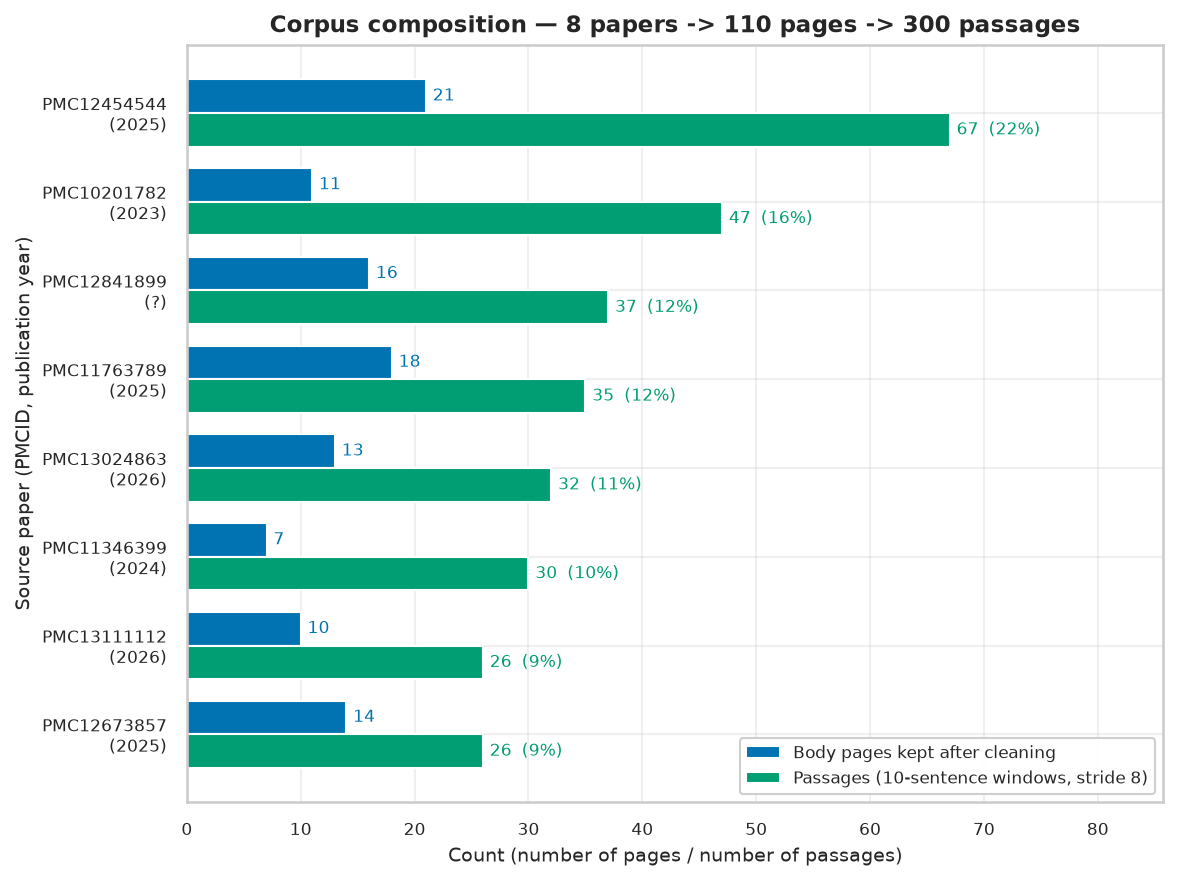

saved -> pde5_figures/fig01_corpus_composition.png  (300 DPI)
최다 기여 : PMC12454544  67/300 passages (22.3%)
최소 기여 : PMC12673857  26/300 passages (8.7%)  → 편차 2.6배
페이지당 패시지 : 평균 2.73개 (같은 페이지라도 문장이 많으면 창이 더 나온다)


In [15]:
pages_per_paper    = collections.Counter(p.pmcid for p in PAGES)
passages_per_paper = collections.Counter(p.pmcid for p in PASSAGES)
year_of            = {r.pmcid: r.year for r in CATALOGUE}

order      = [pmcid for pmcid, _ in passages_per_paper.most_common()]
n_pages    = [pages_per_paper[p] for p in order]
n_passages = [passages_per_paper[p] for p in order]
total_pass = sum(n_passages)

y = np.arange(len(order))
bar_h = 0.38

fig, ax = plt.subplots(figsize=(8.4, 0.62 * len(order) + 1.6))
ax.barh(y - bar_h / 2, n_pages, height=bar_h, color=CB[0],
        label="Body pages kept after cleaning")
ax.barh(y + bar_h / 2, n_passages, height=bar_h, color=CB[2],
        label="Passages (10-sentence windows, stride 8)")

for i, (pg, ps) in enumerate(zip(n_pages, n_passages)):
    ax.text(pg + 0.6, i - bar_h / 2, f"{pg}", va="center", fontsize=8, color=CB[0])
    ax.text(ps + 0.6, i + bar_h / 2, f"{ps}  ({ps / total_pass * 100:.0f}%)",
            va="center", fontsize=8, color=CB[2])

ax.set_yticks(y)
ax.set_yticklabels([f"{pid}\n({year_of.get(pid, '?')})" for pid in order])
ax.invert_yaxis()
ax.set_xlim(0, max(max(n_pages), max(n_passages)) * 1.28)
ax.set_xlabel("Count (number of pages / number of passages)")
ax.set_ylabel("Source paper (PMCID, publication year)")
ax.set_title(f"Corpus composition — {len(order)} papers -> {len(PAGES)} pages -> {total_pass} passages")
ax.legend(loc="lower right", framealpha=0.95)
finish(fig, "fig01_corpus_composition")

top_pid, top_n = passages_per_paper.most_common(1)[0]
min_pid, min_n = passages_per_paper.most_common()[-1]
print(f"최다 기여 : {top_pid}  {top_n}/{total_pass} passages ({top_n / total_pass * 100:.1f}%)")
print(f"최소 기여 : {min_pid}  {min_n}/{total_pass} passages ({min_n / total_pass * 100:.1f}%)"
      f"  → 편차 {top_n / max(min_n, 1):.1f}배")
print(f"페이지당 패시지 : 평균 {total_pass / len(PAGES):.2f}개 "
      f"(같은 페이지라도 문장이 많으면 창이 더 나온다)")

In [16]:
def first_adjacent_pair(passages: list) -> tuple:
    """같은 페이지 안에서 연속한(c00→c01 …) 패시지 쌍을 찾는다.

    청킹은 페이지 단위로 하므로 리스트에서 그냥 이웃한 두 개를 집으면
    페이지 경계를 넘어 겹침이 0으로 나올 수 있다 — 아래 주의 참고.
    """
    for a, b in zip(passages, passages[1:]):
        if a.pmcid == b.pmcid and a.page_no == b.page_no:
            return a, b
    return passages[0], passages[1]


first, second = first_adjacent_pair(PASSAGES)
print(f"같은 페이지 안에서 연속한 두 패시지: {first.uid} → {second.uid}\n")
print(f"[{first.uid}]  …{first.body[-220:]}")
print()
print(f"[{second.uid}]  {second.body[:220]}…")

shared = set(SPLITTER(first.body)) & set(SPLITTER(second.body))
print(f"\n공유 문장 수: {len(shared)}"
      f"  (stride={CFG.sentence_stride}, window={CFG.sentences_per_passage} → 기대값 2)")

crossings = sum(1 for a, b in zip(PASSAGES, PASSAGES[1:])
                if a.pmcid == b.pmcid and a.page_no != b.page_no)
print(f"\n[주의] 페이지 경계 {crossings}곳에서는 겹침이 없다. "
      f"청킹을 페이지 단위로 하기 때문이다 — 개선 과제로 남겨 둔다.")

같은 페이지 안에서 연속한 두 패시지: PMC12841899:p01:c00 → PMC12841899:p01:c01

[PMC12841899:p01:c00]  …n (FAL). Flow cytometric analyses revealed that Sildenafil treatment significantly enhanced platelet-leukocyte aggregate formation, a prerequisite for the subsequent initiation of a lo- calized perivascular inflammation.

[PMC12841899:p01:c01]  Here, we inves- tigated the effects of pharmacological stimulation of the nitric oxide-cyclic guanosine monophosphate (NO-cGMP) signaling pathway using the phosphodiesterase-5 (PDE5) inhibitor Sildenafil on collateral ve…

공유 문장 수: 2  (stride=8, window=10 → 기대값 2)

[주의] 페이지 경계 99곳에서는 겹침이 없다. 청킹을 페이지 단위로 하기 때문이다 — 개선 과제로 남겨 둔다.


## 6. 임베딩과 인덱스

`all-mpnet-base-v2` 는 문장/문단을 **768차원 단위벡터**로 사상한다.
정규화된 벡터끼리의 **내적(dot product)** 은 곧 코사인 유사도이므로,
별도 정규화 없이 `util.dot_score` 로 바로 비교할 수 있다.

인덱스는 **디스크에 저장**한다. 임베딩은 이 파이프라인에서 가장 비싼 단계이고,
코퍼스가 바뀌지 않는 한 다시 계산할 이유가 없다.

- `vectors.npz` — float32 행렬 (N × 768). 텍스트와 분리해 두면 로딩이 빠르다
- `passages.jsonl` — 패시지 메타데이터 한 줄 = 한 개. 사람이 열어볼 수 있다
- `manifest.json` — 어떤 모델·설정으로 만들었는지. **이게 없으면 재현이 불가능하다**

In [17]:
from sentence_transformers import SentenceTransformer, util

ENCODER = SentenceTransformer(CFG.embedder_id, device=DEVICE)

# sentence-transformers 6.x 에서 이름이 바뀐 메서드 — 양쪽 모두 지원
_dim_fn = getattr(ENCODER, "get_embedding_dimension", None) \
          or ENCODER.get_sentence_embedding_dimension
WINDOW_TOKENS = ENCODER.max_seq_length

print(f"임베딩 모델 : {CFG.embedder_id}")
print(f"출력 차원   : {_dim_fn()}")
print(f"최대 입력   : {WINDOW_TOKENS} 토큰")

probe = ENCODER.encode(["sildenafil relaxes vascular smooth muscle"],
                       convert_to_tensor=True)
print(f"\n벡터 shape : {tuple(probe.shape)}")
print(f"L2 norm    : {float(probe.norm()):.4f}  (≈1 이면 정규화된 상태)")
print(f"앞 8개 성분: {[round(float(v), 4) for v in probe[0][:8]]}")

# 모델의 입력 창을 넘는 패시지는 뒷부분이 잘린다 — 알고 쓰는 것과 모르는 것은 다르다
oversize = [p for p in PASSAGES if p.token_estimate > WINDOW_TOKENS]
print(f"\n입력 창({WINDOW_TOKENS} 토큰)을 넘는 패시지: "
      f"{len(oversize)} / {len(PASSAGES)} ({len(oversize)/len(PASSAGES)*100:.0f}%)")
print("  → 초과분은 인코딩 시 절단된다. 창 크기를 줄이거나(예: 6문장) "
      "긴 입력을 받는 모델로 교체하면 완화된다.")

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14417.40it/s]

임베딩 모델 : sentence-transformers/all-mpnet-base-v2
출력 차원   : 768
최대 입력   : 384 토큰



벡터 shape : (1, 768)
L2 norm    : 1.0000  (≈1 이면 정규화된 상태)
앞 8개 성분: [-0.011, -0.0218, 0.0145, 0.018, -0.0155, 0.049, -0.0037, 0.0747]

입력 창(384 토큰)을 넘는 패시지: 87 / 300 (29%)
  → 초과분은 인코딩 시 절단된다. 창 크기를 줄이거나(예: 6문장) 긴 입력을 받는 모델로 교체하면 완화된다.


### 6-1. 그림 2 — 잘리는 패시지가 얼마나 되나

바로 위 셀이 숫자로 알려준 "입력 창 초과" 문제를 분포로 본다.
점선이 mpnet의 입력 한계이고, 그 오른쪽 막대는 **뒷부분이 인코딩에서 통째로 버려지는 패시지**다.
오른쪽 누적분포에서 한계선의 y값을 읽으면 "몇 %가 온전히 들어가는가"를 바로 확인할 수 있다.

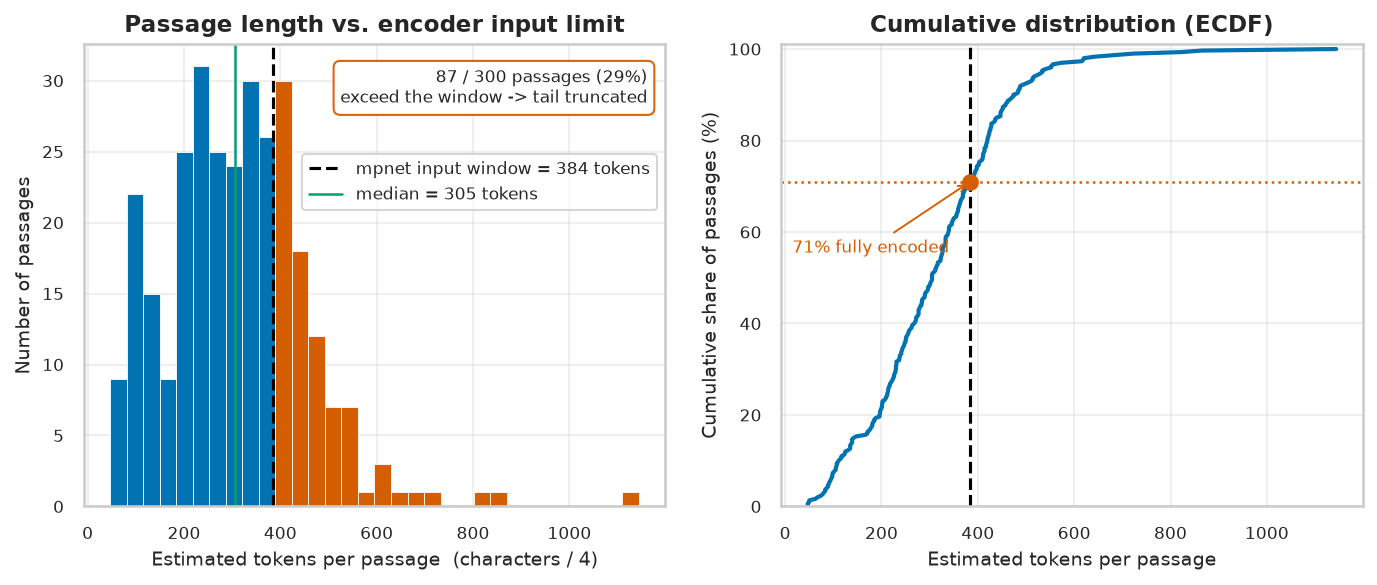

saved -> pde5_figures/fig02_passage_length.png  (300 DPI)
문자 길이 : 최소 189 / 중앙값 1,220 / 최대 4,576
추정 토큰 : 최소 47 / 중앙값 305 / 최대 1144
한계(384 토큰) 초과 : 87 / 300  (29.0%)
  → 창 크기(CFG.sentences_per_passage)를 줄이면 이 비율이 떨어진다. 직접 바꿔 다시 그려 볼 것.


In [18]:
token_est = np.array([p.token_estimate for p in PASSAGES])
char_len  = np.array([len(p.body) for p in PASSAGES])
limit     = WINDOW_TOKENS
n_over    = int((token_est > limit).sum())
frac_over = n_over / len(token_est)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

# (좌) 히스토그램 + 한계선
ax = axes[0]
bins = np.histogram_bin_edges(token_est, bins=32)
counts, _, patches = ax.hist(token_est, bins=bins, color=CB[0],
                             edgecolor="white", linewidth=0.4)
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= limit:
        patch.set_facecolor(CB[3])          # 한계를 넘는 구간만 강조
ax.axvline(limit, color="black", linestyle="--", linewidth=1.5,
           label=f"mpnet input window = {limit} tokens")
ax.axvline(np.median(token_est), color=CB[2], linestyle="-", linewidth=1.2,
           label=f"median = {np.median(token_est):.0f} tokens")
ax.text(0.97, 0.95,
        f"{n_over} / {len(token_est)} passages ({frac_over * 100:.0f}%)\nexceed the window -> tail truncated",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=CB[3], alpha=0.95))
ax.set_xlabel("Estimated tokens per passage  (characters / 4)")
ax.set_ylabel("Number of passages")
ax.set_title("Passage length vs. encoder input limit")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.78))

# (우) 누적분포
ax = axes[1]
xs = np.sort(token_est)
ys = np.arange(1, len(xs) + 1) / len(xs) * 100
ax.plot(xs, ys, color=CB[0], linewidth=2.0)
ax.axvline(limit, color="black", linestyle="--", linewidth=1.5)
ax.axhline((1 - frac_over) * 100, color=CB[3], linestyle=":", linewidth=1.2)
ax.plot([limit], [(1 - frac_over) * 100], marker="o", ms=7, color=CB[3], zorder=5)
ax.annotate(f"{(1 - frac_over) * 100:.0f}% fully encoded",
            xy=(limit, (1 - frac_over) * 100), xytext=(-10, -34),
            textcoords="offset points", ha="right", fontsize=8, color=CB[3],
            arrowprops=dict(arrowstyle="->", color=CB[3], lw=0.9))
ax.set_ylim(0, 101)
ax.set_xlabel("Estimated tokens per passage")
ax.set_ylabel("Cumulative share of passages (%)")
ax.set_title("Cumulative distribution (ECDF)")

finish(fig, "fig02_passage_length")

print(f"문자 길이 : 최소 {char_len.min():,} / 중앙값 {int(np.median(char_len)):,} / 최대 {char_len.max():,}")
print(f"추정 토큰 : 최소 {token_est.min()} / 중앙값 {int(np.median(token_est))} / 최대 {token_est.max()}")
print(f"한계({limit} 토큰) 초과 : {n_over} / {len(token_est)}  ({frac_over * 100:.1f}%)")
print("  → 창 크기(CFG.sentences_per_passage)를 줄이면 이 비율이 떨어진다. 직접 바꿔 다시 그려 볼 것.")

In [19]:
import numpy as np
import time


class PassageIndex:
    """패시지 + 벡터를 함께 들고 다니는 최소한의 벡터 스토어."""

    def __init__(self, passages: list, matrix: "torch.Tensor", manifest: dict):
        self.passages = passages
        self.matrix = matrix
        self.manifest = manifest

    def __len__(self) -> int:
        return len(self.passages)

    # ---------- 생성 ----------
    @classmethod
    def build(cls, passages: list, encoder: SentenceTransformer,
              config: PipelineConfig) -> "PassageIndex":
        """패시지 목록을 인코더로 임베딩해 검색용 인덱스 객체를 만든다."""
        started = time.time()
        matrix = encoder.encode(
            [p.body for p in passages],
            batch_size=config.encode_batch,
            convert_to_tensor=True,
            show_progress_bar=False,
        )
        manifest = {
            "embedder_id": config.embedder_id,
            "dimension": int(matrix.shape[1]),
            "n_passages": len(passages),
            "sentences_per_passage": config.sentences_per_passage,
            "sentence_stride": config.sentence_stride,
            "min_passage_tokens": config.min_passage_tokens,
            "build_seconds": round(time.time() - started, 1),
        }
        return cls(passages, matrix, manifest)

    # ---------- 저장 / 로딩 ----------
    def save(self, directory: Path) -> Path:
        """벡터·패시지·매니페스트를 디렉터리에 저장하고 그 경로를 돌려준다."""
        directory.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(directory / "vectors.npz",
                            matrix=self.matrix.cpu().numpy().astype("float32"))
        with (directory / "passages.jsonl").open("w", encoding="utf-8") as fh:
            for p in self.passages:
                fh.write(json.dumps(asdict(p), ensure_ascii=False) + "\n")
        (directory / "manifest.json").write_text(
            json.dumps(self.manifest, ensure_ascii=False, indent=2), encoding="utf-8")
        return directory

    @classmethod
    def load(cls, directory: Path, device: str = "cpu") -> "PassageIndex":
        """디스크에 저장한 인덱스를 다시 읽어 동일한 객체로 복원한다."""
        matrix = torch.from_numpy(np.load(directory / "vectors.npz")["matrix"]).to(device)
        passages = [Passage(**json.loads(line))
                    for line in (directory / "passages.jsonl").read_text(encoding="utf-8").splitlines()]
        manifest = json.loads((directory / "manifest.json").read_text(encoding="utf-8"))
        return cls(passages, matrix, manifest)

    # ---------- 검색 ----------
    def query(self, question: str, encoder: SentenceTransformer, k: int = 5) -> list:
        """질의를 임베딩해 내적 유사도 상위 k개 패시지를 돌려준다."""
        query_vec = encoder.encode(question, convert_to_tensor=True).to(self.matrix.device)
        scores = util.dot_score(query_vec, self.matrix)[0]
        best = torch.topk(scores, k=min(k, len(self)))
        return [Retrieved(self.passages[int(i)], float(s))
                for s, i in zip(best.values, best.indices)]


@dataclass
class Retrieved:
    """검색으로 뽑힌 패시지 하나와 그 유사도 점수를 묶은 값 객체."""
    passage: Passage
    score: float

In [20]:
INDEX = PassageIndex.build(PASSAGES, ENCODER, CFG)
print(json.dumps(INDEX.manifest, ensure_ascii=False, indent=2))


saved_to = INDEX.save(CFG.index_dir)
for artefact in sorted(saved_to.iterdir()):
    print(f"{artefact.name:<18} {artefact.stat().st_size/1024:>9,.1f} KB")

{
  "embedder_id": "sentence-transformers/all-mpnet-base-v2",
  "dimension": 768,
  "n_passages": 300,
  "sentences_per_passage": 10,
  "sentence_stride": 8,
  "min_passage_tokens": 32,
  "build_seconds": 109.7
}
manifest.json            0.2 KB
passages.jsonl         393.7 KB
vectors.npz            836.9 KB


In [21]:
# 저장한 인덱스를 다시 읽어 동일성을 확인한다 — 재현성 점검
RELOADED = PassageIndex.load(CFG.index_dir, device=DEVICE)

print(f"패시지 수 일치 : {len(RELOADED) == len(INDEX)}")
print(f"행렬 shape     : {tuple(RELOADED.matrix.shape)}")
print(f"최대 오차      : {float((RELOADED.matrix - INDEX.matrix).abs().max()):.2e}  (float32 반올림 수준)")

패시지 수 일치 : True
행렬 shape     : (300, 768)
최대 오차      : 0.00e+00  (float32 반올림 수준)


## 7. 검색 (Retrieval)

질의도 같은 인코더로 임베딩한 뒤 `util.dot_score` 로 전체 패시지와의 유사도를 구하고
`torch.topk` 로 상위 k개를 뽑는다. 이것이 RAG의 R 전부다.

점수를 읽는 법 — 이 모델·이 코퍼스 기준의 대략적인 감:

| 점수대 | 해석 |
|--------|------|
| 0.70 이상 | 질의를 직접 다루는 문단. 근거로 쓸 만하다 |
| 0.55 ~ 0.70 | 주제는 맞지만 초점이 어긋남. 보조 문맥 |
| 0.55 미만 | 사실상 무관. k를 키워도 얻을 게 없다 |

In [22]:
def show_hits(hits: list, width: int = 260) -> None:
    """검색 결과를 점수·출처·본문 미리보기 형태로 화면에 출력한다."""
    for rank, hit in enumerate(hits, 1):
        p = hit.passage
        print(f"[{rank}] score={hit.score:.4f}   {p.citation()}   ({p.n_sentences}문장)")
        print(f"     {p.body[:width]}…")
        print()

In [23]:
QUERY_MECHANISM = "mechanism of sildenafil as a PDE5 inhibitor"

hits_mechanism = RELOADED.query(QUERY_MECHANISM, ENCODER, k=CFG.top_k)
print(f"질의: {QUERY_MECHANISM}\n")
show_hits(hits_mechanism)

질의: mechanism of sildenafil as a PDE5 inhibitor

[1] score=0.8243   PMC12454544 p.16   (10문장)
     PDES inhibitors should also be used with caution and under medical supervision by patients with severe renal impairment and hepatic cirrhosis because of decreased drug clearance from the blood, leading to increased expo- sure to the drug effects. Furthermore, …

[2] score=0.8159   PMC12454544 p.3   (5문장)
     Pyrazolopyrimidinones [30-32] Sildenafil citrate (viagra®) (First generation PDE5 inhibitor) [30] Sildenafil citrate, (1-[[3-(6,7-dihydro-1-methyl-7-oxo- 3-propyl-1H-pyrazolo[4,3-d]pyrimidin-5-yl)-4-ethoxyphe- nyl]sulfonyl]-4-methyl piperazine), is the first o…

[3] score=0.7961   PMC12454544 p.15   (10문장)
     Aildenafil citrate has been also evaluated for treatment of ED though phase I clinical trials on 20 patients after multiple oral administration of 30mg and 60 mg doses [134]. Examples of PDE5 inhibitors in clinical trials are shown in Table 3. Pharmacokinetics…

[4] score=0.78

In [24]:
QUERY_SAFETY = "cardiovascular safety and arrhythmia risk of PDE5 inhibitors"

hits_safety = RELOADED.query(QUERY_SAFETY, ENCODER, k=CFG.top_k)
print(f"질의: {QUERY_SAFETY}\n")
show_hits(hits_safety)


# 코퍼스가 넓어진 만큼 결이 다른 세 번째 질의도 던져 본다
QUERY_REPRODUCTION = "effect of PDE5 inhibitors on male reproduction and sperm function"

hits_reproduction = RELOADED.query(QUERY_REPRODUCTION, ENCODER, k=CFG.top_k)
print(f"질의: {QUERY_REPRODUCTION}"
      f"   (top-1 score={hits_reproduction[0].score:.4f})\n")


# 세 질의가 실제로 서로 다른 논문을 불러오는지 — 코퍼스 다양성 확인
def sources_of(hits: list) -> str:
    """검색 결과에 등장한 논문 PMCID 를 중복 없이 이어 붙인 문자열."""
    return ", ".join(sorted({h.passage.pmcid for h in hits}))

print(f"기전 질의   → {sources_of(hits_mechanism)}")
print(f"안전성 질의 → {sources_of(hits_safety)}")
print(f"생식 질의   → {sources_of(hits_reproduction)}")

질의: cardiovascular safety and arrhythmia risk of PDE5 inhibitors

[1] score=0.8443   PMC12673857 p.10   (10문장)
     In addition to two systematic reviews/meta-analyses on the long-term cardiovascular effects of PDE-5 inhibitors20 and the cardiovascular effects of PDE-5 inhibitors in diabetic populations21. The following section discusses the similarities, differences, and n…

[2] score=0.8279   PMC12673857 p.2   (8문장)
     However, in circumstances where decreased blood pressure is not desirable in CVD patients, PDE5 inhibitors may not be helpful or are even contraindicated. For example, PDE5 inhibitors have been found to have negative effects in patients taking nitrates, patien…

[3] score=0.8225   PMC12673857 p.9   (10문장)
     in enhancing microvascular function and subsequent vascular health in hypertensive patients. Further evidence of reduced cardiovascular risk using ED treatment was found in a nationwide cohort study by Vestergaard et al.13. Using data from over one million men…

질의: effect of PDE5 inhibitors on male reproduction and sperm function   (top-1 score=0.9115)

기전 질의   → PMC12454544
안전성 질의 → PMC12673857
생식 질의   → PMC11763789


### 7-1. 그림 3 — top-k는 꼬리에서 얼마나 떨어져 나오는가

검색은 "상위 k개를 고르는" 일이지만, **그 k개가 나머지와 얼마나 벌어져 있는지**가 실제 품질을 결정한다.
질의마다 전체 패시지 300개의 점수 분포(회색)를 그리고, 실제 선택된 top-k를 삼각형으로 얹었다.
위 표의 해석 기준선(0.55 / 0.70)도 같이 그려 두었다 — **꼬리와 붙어 있는 top-1은 신뢰하기 어렵다**는 감각을 준다.

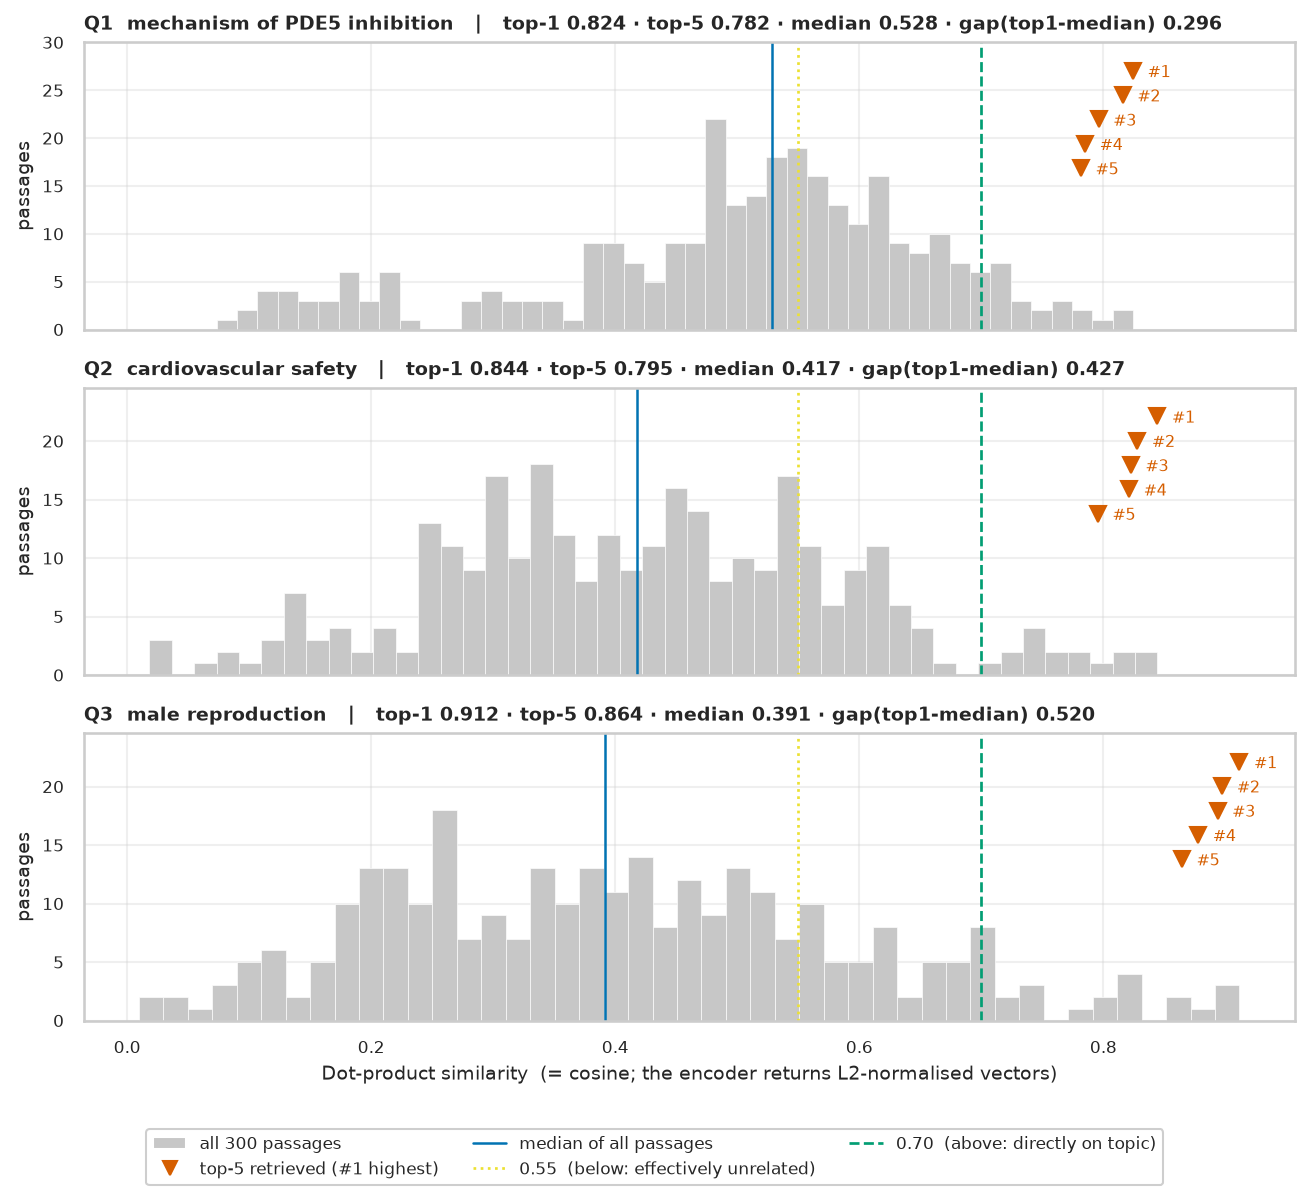

saved -> pde5_figures/fig03_score_distribution.png  (300 DPI)
query                                 top1   top-k  median  top1-median
Q1  mechanism of PDE5 inhibition     0.824   0.782   0.528        0.296
Q2  cardiovascular safety            0.844   0.795   0.417        0.427
Q3  male reproduction                0.912   0.864   0.391        0.520

분포의 몸통은 0.2~0.4 근처에 몰려 있고 top-k만 오른쪽 꼬리에 떨어져 나온다.
꼬리가 두꺼워지면(=gap이 작아지면) 임계값으로 걸러내기가 어려워진다 — k만 키우는 것은 답이 아니다.


In [25]:
QUERY_SET = [
    ("Q1  mechanism of PDE5 inhibition", QUERY_MECHANISM),
    ("Q2  cardiovascular safety", QUERY_SAFETY),
    ("Q3  male reproduction", QUERY_REPRODUCTION),
]


def all_scores(index: PassageIndex, question: str) -> np.ndarray:
    """질의 하나에 대한 전체 패시지 점수 벡터 (패시지 임베딩은 재사용, 질의만 새로 인코딩)."""
    qv = ENCODER.encode(question, convert_to_tensor=True).to(index.matrix.device)
    return util.dot_score(qv, index.matrix)[0].cpu().numpy()


fig, axes = plt.subplots(len(QUERY_SET), 1, figsize=(8.8, 7.4), sharex=True)
summary = []

for ax, (label, question) in zip(axes, QUERY_SET):
    scores = all_scores(RELOADED, question)
    top = np.sort(scores)[-CFG.top_k:][::-1]
    ax.hist(scores, bins=45, color="0.78", edgecolor="white", linewidth=0.3)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.30)                      # 마커를 올려놓을 위쪽 여백
    for rank, sc in enumerate(top, 1):
        marker_y = ymax * (1.17 - 0.11 * (rank - 1))  # 순위마다 높이를 낮춰 라벨 충돌 방지
        ax.plot([sc], [marker_y], "v", color=CB[3], ms=8, zorder=5)
        ax.annotate(f"#{rank}", xy=(sc, marker_y), xytext=(7, -1),
                    textcoords="offset points", ha="left", va="center",
                    fontsize=7.5, color=CB[3])
    ax.axvline(np.median(scores), color=CB[0], linewidth=1.2)
    ax.axvline(0.55, color=CB[8], linestyle=":", linewidth=1.3)
    ax.axvline(0.70, color=CB[2], linestyle="--", linewidth=1.3)
    ax.set_ylabel("passages")
    ax.set_title(
        f"{label}   |   top-1 {top[0]:.3f} · top-{CFG.top_k} {top[-1]:.3f} · "
        f"median {np.median(scores):.3f} · gap(top1-median) {top[0] - np.median(scores):.3f}",
        loc="left", fontsize=9)
    summary.append((label, top[0], top[-1], float(np.median(scores)), float(scores.max())))

axes[-1].set_xlabel("Dot-product similarity  (= cosine; the encoder returns L2-normalised vectors)")
fig.tight_layout()
fig.legend(handles=[                                  # 막대도 x축 라벨도 가리지 않도록 그림 밖(아래)에 배치
    Patch(facecolor="0.78", edgecolor="white", label=f"all {len(RELOADED)} passages"),
    Line2D([], [], marker="v", color=CB[3], ls="", ms=7, label=f"top-{CFG.top_k} retrieved (#1 highest)"),
    Line2D([], [], color=CB[0], lw=1.2, label="median of all passages"),
    Line2D([], [], color=CB[8], ls=":", lw=1.3, label="0.55  (below: effectively unrelated)"),
    Line2D([], [], color=CB[2], ls="--", lw=1.3, label="0.70  (above: directly on topic)"),
], loc="upper center", bbox_to_anchor=(0.5, -0.015), ncols=3, framealpha=0.95)

finish(fig, "fig03_score_distribution")

print(f"{'query':<34} {'top1':>7} {'top-k':>7} {'median':>7} {'top1-median':>12}")
for label, t1, tk, med, _ in summary:
    print(f"{label:<34} {t1:>7.3f} {tk:>7.3f} {med:>7.3f} {t1 - med:>12.3f}")
print("\n분포의 몸통은 0.2~0.4 근처에 몰려 있고 top-k만 오른쪽 꼬리에 떨어져 나온다.")
print("꼬리가 두꺼워지면(=gap이 작아지면) 임계값으로 걸러내기가 어려워진다 — k만 키우는 것은 답이 아니다.")

### 7-2. 그림 4 — 질의마다 다른 논문이 뽑힌다 (라우팅 히트맵)

앞에서 세 질의의 출처 PMCID를 텍스트로 확인했다. 질의를 다섯 개로 늘려 **질의 × 논문** 행렬로 그리면
"검색이 실제로 주제를 구분하고 있는가"가 색으로 드러난다.
대각선처럼 특정 칸에 몰리면 라우팅이 잘 되는 것이고, 한 열이 모든 행에서 밝으면 그 논문이 코퍼스를 지배한다는 뜻이다.

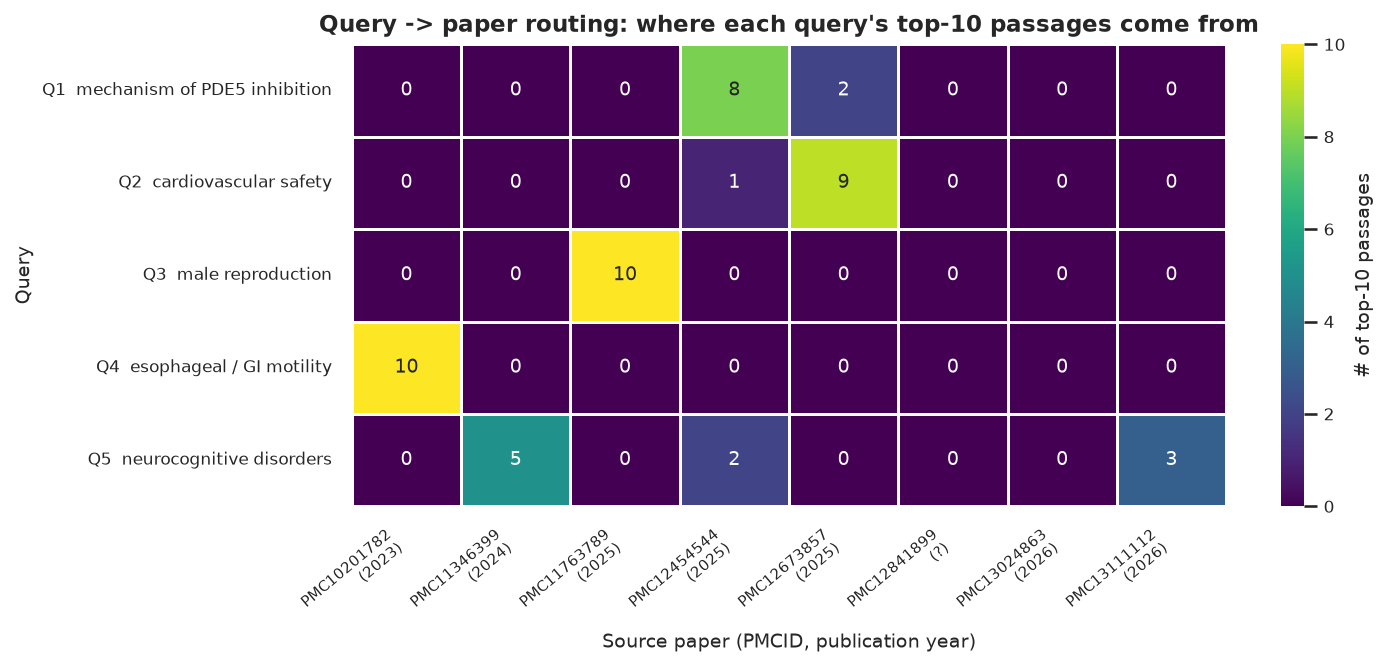

saved -> pde5_figures/fig04_routing_heatmap.png  (300 DPI)
query                              papers hit   dominant paper
Q1  mechanism of PDE5 inhibition            2   PMC12454544 (8/10)
Q2  cardiovascular safety                   2   PMC12673857 (9/10)
Q3  male reproduction                       1   PMC11763789 (10/10)
Q4  esophageal / GI motility                1   PMC10201782 (10/10)
Q5  neurocognitive disorders                3   PMC11346399 (5/10)

질의 쌍별 출처 논문 겹침 (Jaccard, 0=완전히 다른 논문 / 1=동일)
  Q1  vs Q2  : 1.00   (공통 ['PMC12454544', 'PMC12673857'])
  Q1  vs Q3  : 0.00   (공통 없음)
  Q1  vs Q4  : 0.00   (공통 없음)
  Q1  vs Q5  : 0.25   (공통 ['PMC12454544'])
  Q2  vs Q3  : 0.00   (공통 없음)
  Q2  vs Q4  : 0.00   (공통 없음)
  Q2  vs Q5  : 0.25   (공통 ['PMC12454544'])
  Q3  vs Q4  : 0.00   (공통 없음)
  Q3  vs Q5  : 0.00   (공통 없음)
  Q4  vs Q5  : 0.00   (공통 없음)

※ 히트맵 값은 코퍼스·모델 버전에 따라 달라질 수 있다. 재실행 시 자기 출력 기준으로 읽을 것.


In [26]:
ROUTING_QUERIES = {
    "Q1  mechanism of PDE5 inhibition": QUERY_MECHANISM,
    "Q2  cardiovascular safety":        QUERY_SAFETY,
    "Q3  male reproduction":            QUERY_REPRODUCTION,
    "Q4  esophageal / GI motility":     "PDE5 inhibitors and esophageal motility or gastrointestinal smooth muscle",
    "Q5  neurocognitive disorders":     "PDE5 inhibition in neurocognitive disorders, dementia and polypharmacology",
}
K_ROUTE = 10

papers  = sorted({p.pmcid for p in RELOADED.passages})
year_of = {r.pmcid: r.year for r in CATALOGUE}
routing = np.zeros((len(ROUTING_QUERIES), len(papers)), dtype=int)
route_hits = {}

for i, (label, question) in enumerate(ROUTING_QUERIES.items()):
    hits = RELOADED.query(question, ENCODER, k=K_ROUTE)
    route_hits[label] = hits
    for hit in hits:
        routing[i, papers.index(hit.passage.pmcid)] += 1

fig, ax = plt.subplots(figsize=(9.4, 4.0))
sns.heatmap(routing, ax=ax, cmap="viridis", annot=True, fmt="d",
            linewidths=0.7, linecolor="white", vmin=0,
            cbar_kws={"label": f"# of top-{K_ROUTE} passages"},
            xticklabels=[f"{p}\n({year_of.get(p, '?')})" for p in papers],
            yticklabels=list(ROUTING_QUERIES))
ax.set_xlabel("Source paper (PMCID, publication year)")
ax.set_ylabel("Query")
ax.set_title(f"Query -> paper routing: where each query's top-{K_ROUTE} passages come from")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
finish(fig, "fig04_routing_heatmap")

print(f"{'query':<34} {'papers hit':>10}   dominant paper")
for i, label in enumerate(ROUTING_QUERIES):
    row = routing[i]
    hit_papers = int((row > 0).sum())
    j = int(row.argmax())
    print(f"{label:<34} {hit_papers:>10}   {papers[j]} ({row[j]}/{K_ROUTE})")

labels = list(ROUTING_QUERIES)
print("\n질의 쌍별 출처 논문 겹침 (Jaccard, 0=완전히 다른 논문 / 1=동일)")
for a in range(len(labels)):
    for b in range(a + 1, len(labels)):
        sa = {papers[j] for j in np.nonzero(routing[a])[0]}
        sb = {papers[j] for j in np.nonzero(routing[b])[0]}
        print(f"  {labels[a][:3]} vs {labels[b][:3]} : {len(sa & sb) / len(sa | sb):.2f}"
              f"   (공통 {sorted(sa & sb) or '없음'})")
print("\n※ 히트맵 값은 코퍼스·모델 버전에 따라 달라질 수 있다. 재실행 시 자기 출력 기준으로 읽을 것.")

### 7-3. 그림 5 — 임베딩 공간에서 질의는 어디에 떨어지나

768차원은 볼 수 없으니 PCA로 2차원만 남긴다(설명 분산은 그림의 축 라벨에 표시된다 — **대부분의 정보는 버려진다**).
점 = 패시지(색은 출처 논문), 별(★) = 질의 벡터다. 질의 근처에 어떤 색이 모여 있는지가 곧 그림 4의 라우팅이다.
2D에서 겹쳐 보이는 점들이 실제로는 고차원에서 멀 수 있다는 점은 감안하고 봐야 한다.

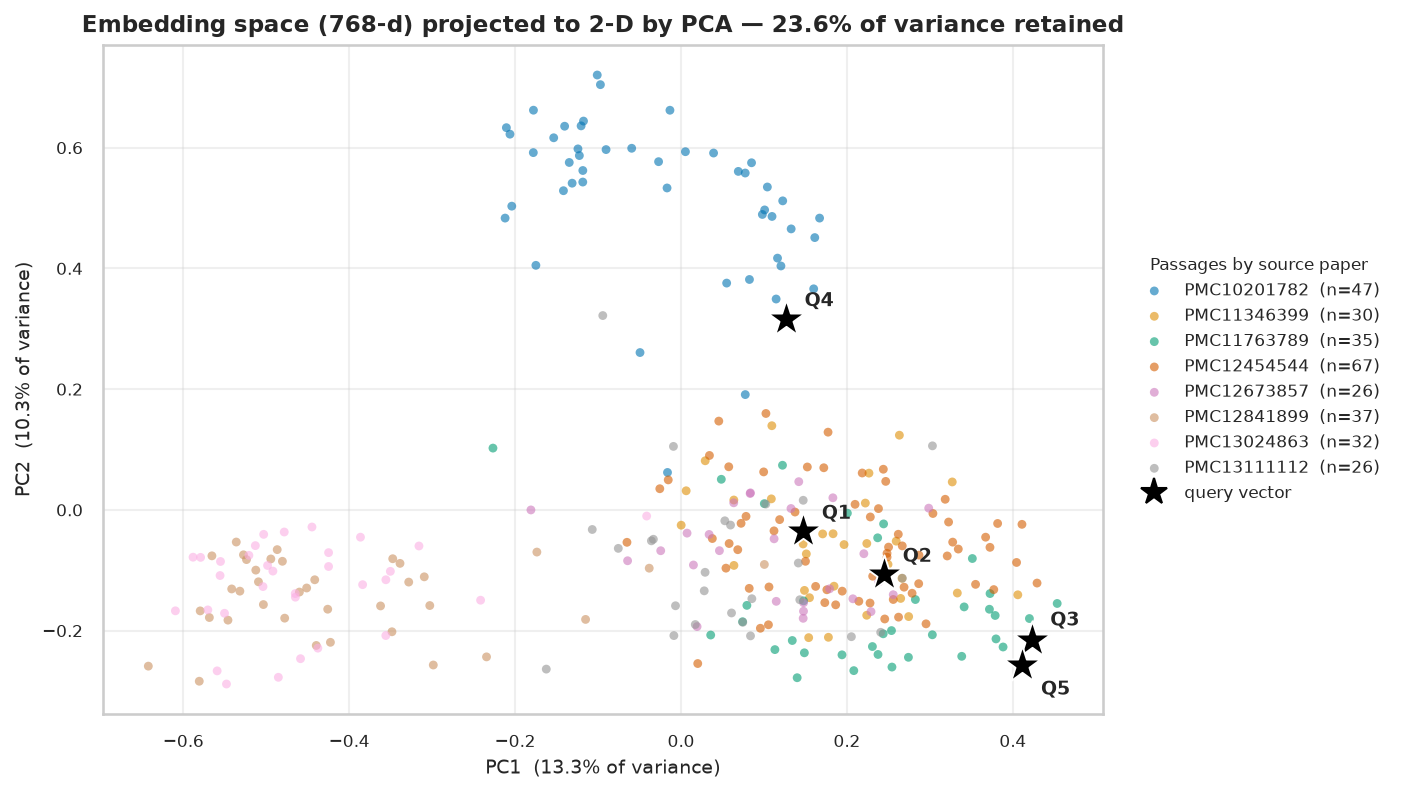

saved -> pde5_figures/fig05_embedding_pca.png  (300 DPI)
PC1+PC2 로 설명되는 분산: 23.6% — 나머지 76.4% 는 이 그림에 없다.
따라서 '가까워 보인다'는 참고일 뿐, 실제 검색은 언제나 768차원 내적으로 이뤄진다.


In [27]:
from sklearn.decomposition import PCA

X = RELOADED.matrix.cpu().numpy()
pca = PCA(n_components=2, random_state=0).fit(X)
XY = pca.transform(X)

query_vecs = ENCODER.encode(list(ROUTING_QUERIES.values()), convert_to_numpy=True)
QXY = pca.transform(np.asarray(query_vecs))

colours = paper_palette([p.pmcid for p in RELOADED.passages])
fig, ax = plt.subplots(figsize=(8.6, 5.8))

for pmcid in sorted(colours):
    idx = [i for i, p in enumerate(RELOADED.passages) if p.pmcid == pmcid]
    ax.scatter(XY[idx, 0], XY[idx, 1], s=18, alpha=0.6, color=colours[pmcid],
               edgecolors="none", label=f"{pmcid}  (n={len(idx)})")

# 별이 몰려 있어도 라벨이 겹치지 않도록 질의마다 라벨 방향을 다르게 준다
LABEL_OFFSETS = [(9, 6), (9, 6), (9, 7), (9, 6), (9, -14)]
for i, ((label, _), (qx, qy)) in enumerate(zip(ROUTING_QUERIES.items(), QXY)):
    ax.scatter([qx], [qy], marker="*", s=340, color="black",
               edgecolors="white", linewidths=0.9, zorder=6)
    ax.annotate(label.split()[0], xy=(qx, qy),
                xytext=LABEL_OFFSETS[i % len(LABEL_OFFSETS)],
                textcoords="offset points", fontsize=9, fontweight="bold", zorder=7)

ax.set_xlabel(f"PC1  ({pca.explained_variance_ratio_[0] * 100:.1f}% of variance)")
ax.set_ylabel(f"PC2  ({pca.explained_variance_ratio_[1] * 100:.1f}% of variance)")
ax.set_title(f"Embedding space (768-d) projected to 2-D by PCA — "
             f"{pca.explained_variance_ratio_.sum() * 100:.1f}% of variance retained")

handles, legend_labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], marker="*", color="black", ls="", ms=13, label="query vector"))
legend_labels.append("query vector")
ax.legend(handles, legend_labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, title="Passages by source paper", title_fontsize=8)
finish(fig, "fig05_embedding_pca")

print(f"PC1+PC2 로 설명되는 분산: {pca.explained_variance_ratio_.sum() * 100:.1f}% "
      f"— 나머지 {100 - pca.explained_variance_ratio_.sum() * 100:.1f}% 는 이 그림에 없다.")
print("따라서 '가까워 보인다'는 참고일 뿐, 실제 검색은 언제나 768차원 내적으로 이뤄진다.")

### 7-4. 전처리가 검색에 미친 영향

4절에서 걸러낸 참고문헌·머리말이 남아 있었다면 어떻게 됐을까?
직접 확인해 보자. 필터를 끄고 인덱스를 다시 만들어 같은 질의를 던진다.

In [28]:
class NaivePassageBuilder(PassageBuilder):
    """대조군: 참고문헌·머리말 필터를 끈 채로 패시지를 만드는 빌더."""
    """비교용: 길이 필터만 적용하고 참고문헌 판별은 하지 않는다."""

    def build(self, pages: list) -> list:
        """필터를 끈 채로 패시지를 만든다 — 전처리 효과를 대조하기 위한 버전."""
        passages = []
        for page in pages:
            for order, window in enumerate(self._windows(self.splitter(page.body))):
                body = " ".join(window)
                candidate = Passage(
                    uid=f"{page.pmcid}:p{page.page_no:02d}:c{order:02d}",
                    pmcid=page.pmcid, page_no=page.page_no,
                    body=body, n_sentences=len(window),
                )
                if candidate.token_estimate >= self.min_tokens:
                    passages.append(candidate)
        return passages


# 참고문헌 절단 이전의 '날것' 페이지를 다시 만든다
def raw_pages_of(ref: PaperRef) -> list:
    """정제 없이 PDF 원문 그대로의 페이지 텍스트를 돌려준다."""
    with pymupdf.open(ref.pdf_path) as document:
        return [PageText(ref.pmcid, i, collapse(normalise(page.get_text())))
                for i, page in enumerate(document, start=1)
                if len(collapse(normalise(page.get_text()))) >= 120]


RAW_PAGES = [p for ref in LIBRARY for p in raw_pages_of(ref)]
NAIVE_PASSAGES = NaivePassageBuilder(CFG, SPLITTER).build(RAW_PAGES)
print(f"정제 파이프라인 : {len(PASSAGES)} 패시지")
print(f"무정제 파이프라인: {len(NAIVE_PASSAGES)} 패시지")


NAIVE_INDEX = PassageIndex.build(NAIVE_PASSAGES, ENCODER, CFG)
naive_hits = NAIVE_INDEX.query(QUERY_SAFETY, ENCODER, k=3)

print(f"[무정제] {QUERY_SAFETY}\n")
show_hits(naive_hits, width=200)
print("=" * 90)
print(f"[정제됨] {QUERY_SAFETY}\n")
show_hits(hits_safety[:3], width=200)

정제 파이프라인 : 300 패시지
무정제 파이프라인: 593 패시지


[무정제] cardiovascular safety and arrhythmia risk of PDE5 inhibitors

[1] score=0.8295   PMC12673857 p.2   (9문장)
     For instance, recent studies have shown that PDE5 inhibitors have positive effects on pulmonary arterial hypertension8. However, in circumstances where decreased blood pressure is not desirable in CVD…

[2] score=0.8159   PMC12673857 p.12   (4문장)
     CONCLUSION This systematic review highlights the dual benefits of PDE5 inhibitors in treating ED and improving cardiovascular outcomes in patients with coexisting CVD. These medications show promise i…

[3] score=0.8085   PMC12673857 p.9   (10문장)
     Page 9 of 14 Ghantous et al., GCSP 2025:31 in enhancing microvascular function and subsequent vascular health in hypertensive patients. Further evidence of reduced cardiovascular risk using ED treatme…

[정제됨] cardiovascular safety and arrhythmia risk of PDE5 inhibitors

[1] score=0.8443   PMC12673857 p.10   (10문장)
     In addition to two systematic reviews/meta-analyses on the 

### 7-5. 그림 6 — 필터를 끄면 인덱스에 무엇이 남는가

같은 질의·같은 모델·같은 청킹이고 **참고문헌 판별만 껐다**. 왼쪽은 상위 3개의 점수와 출처,
괄호 안은 그 패시지의 인용 표지 밀도(`looks_like_bibliography` 가 보는 지표)다.
오른쪽이 핵심이다 — 점수는 비슷해 보여도 **무정제 인덱스에는 참고문헌성 패시지가 통째로 남아 있다.**
질의를 바꾸거나 k를 키우는 순간 그것들이 상위로 올라온다.

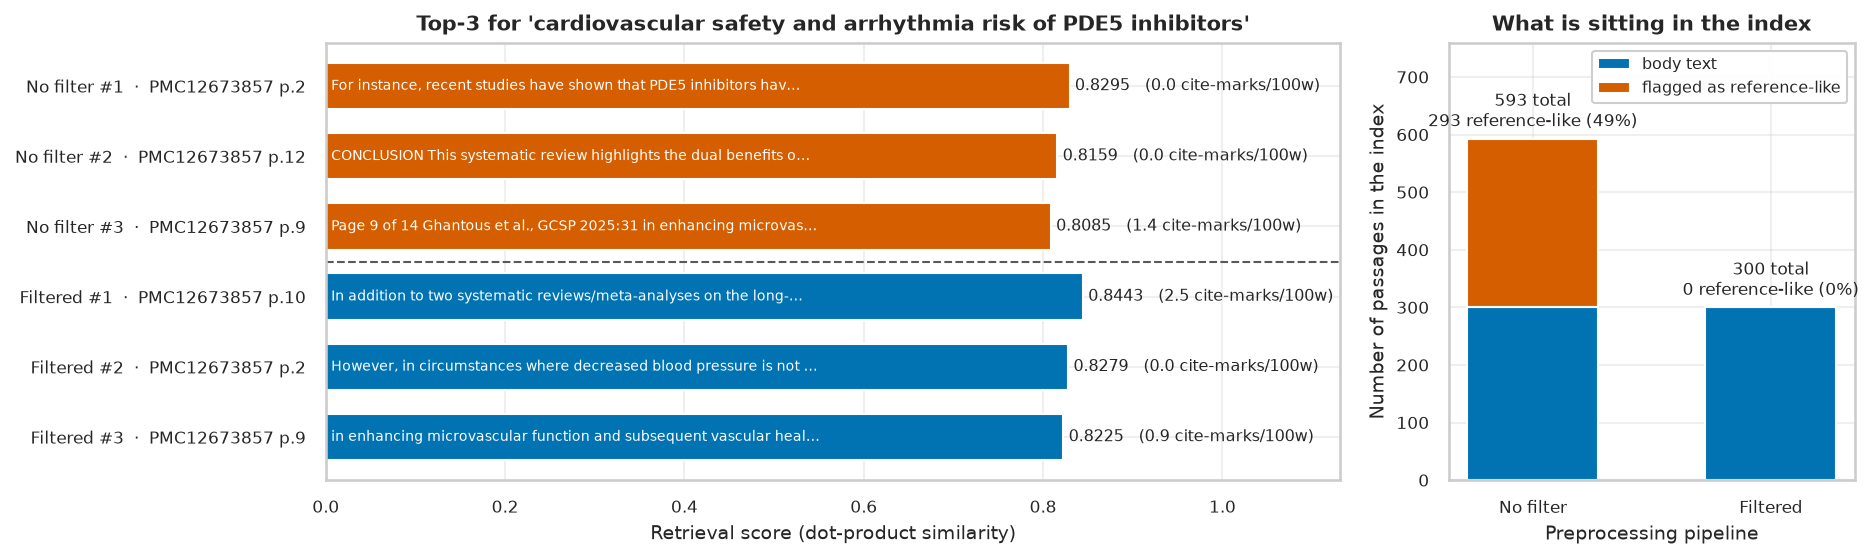

saved -> pde5_figures/fig06_filter_effect.png  (300 DPI)
무정제 인덱스 : 593 passages · 참고문헌성 293개 (49.4%) · top-1 0.8295 (PMC12673857 p.2)
정제 인덱스   : 300 passages · 참고문헌성 0개 (0.0%) · top-1 0.8443 (PMC12673857 p.10)
무정제 상위 20위 안에 들어온 참고문헌성 패시지 : 3개

점수만 보면 두 파이프라인이 비슷해 보인다. 차이는 '무엇이 후보로 남아 있는가' 에 있다 —
k를 키우거나 질의를 바꾸는 순간 무정제 인덱스에서는 저 참고문헌성 패시지들이 올라온다.

※ 실제 점수·순위는 다운로드된 PDF 판본과 모델 버전에 따라 달라질 수 있다.


In [29]:
def marker_density(text: str) -> float:
    """텍스트에서 인용 표지(연도·괄호 숫자 등)가 차지하는 밀도를 잰다."""
    """100단어당 인용 표지(et al., doi:, [12] …) 개수 — looks_like_bibliography 가 쓰는 지표."""
    return _per_100_words(text, len(CITATION_MARKS.findall(text)))


def bar_rows(hits: list, tag: str) -> list:
    """검색 결과를 막대그래프용 (라벨, 점수, 밀도) 행 목록으로 바꾼다."""
    return [
        {
            "label":   f"{tag} #{rank}  ·  {hit.passage.citation()}",
            "score":   hit.score,
            "density": marker_density(hit.passage.body),
            "head":    hit.passage.body[:64].replace("\n", " ") + "…",
            "tag":     tag,
        }
        for rank, hit in enumerate(hits, 1)
    ]


rows = bar_rows(naive_hits, "No filter") + bar_rows(hits_safety[:3], "Filtered")
y = np.arange(len(rows))
scores = [r["score"] for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 3.8),
                         gridspec_kw={"width_ratios": [2.5, 1.0]})

# (좌) 같은 질의의 상위 3개 — 점수와 출처
ax = axes[0]
ax.barh(y, scores, height=0.66, edgecolor="white",
        color=[CB[3] if r["tag"] == "No filter" else CB[0] for r in rows])
for i, r in enumerate(rows):
    ax.text(0.006, i, r["head"], va="center", ha="left", fontsize=6.8, color="white")
    ax.text(r["score"] + 0.006, i, f"{r['score']:.4f}   ({r['density']:.1f} cite-marks/100w)",
            va="center", fontsize=7.5)
ax.axhline(len(naive_hits) - 0.5, color="0.35", lw=1.0, ls="--")
ax.set_yticks(y)
ax.set_yticklabels([r["label"] for r in rows], fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, max(scores) * 1.34)
ax.set_xlabel("Retrieval score (dot-product similarity)")
ax.set_title("Top-3 for 'cardiovascular safety and arrhythmia risk of PDE5 inhibitors'",
             fontsize=10)

# (우) 인덱스 자체의 구성 — 걸러지지 않은 참고문헌성 패시지가 몇 개나 섞여 있나
ax = axes[1]
naive_flagged = sum(looks_like_bibliography(p.body) for p in NAIVE_PASSAGES)
clean_flagged = sum(looks_like_bibliography(p.body) for p in PASSAGES)
totals   = [len(NAIVE_PASSAGES), len(PASSAGES)]
flagged  = [naive_flagged, clean_flagged]
body     = [t - f for t, f in zip(totals, flagged)]
xpos     = np.arange(2)
ax.bar(xpos, body, width=0.55, color=CB[0], label="body text")
ax.bar(xpos, flagged, width=0.55, bottom=body, color=CB[3],
       label="flagged as reference-like")
for x, (t, f) in enumerate(zip(totals, flagged)):
    ax.text(x, t + max(totals) * 0.02, f"{t} total\n{f} reference-like ({f / t * 100:.0f}%)",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(xpos)
ax.set_xticklabels(["No filter", "Filtered"])
ax.set_ylim(0, max(totals) * 1.28)
ax.set_ylabel("Number of passages in the index")
ax.set_xlabel("Preprocessing pipeline")
ax.set_title("What is sitting in the index", fontsize=10)
ax.legend(loc="upper right", fontsize=7.5, framealpha=0.95)

fig.tight_layout()
finish(fig, "fig06_filter_effect")

deep_naive = NAIVE_INDEX.query(QUERY_SAFETY, ENCODER, k=20)
deep_flagged = sum(looks_like_bibliography(h.passage.body) for h in deep_naive)
print(f"무정제 인덱스 : {len(NAIVE_PASSAGES)} passages · 참고문헌성 {naive_flagged}개 "
      f"({naive_flagged / len(NAIVE_PASSAGES) * 100:.1f}%) · top-1 {naive_hits[0].score:.4f} "
      f"({naive_hits[0].passage.citation()})")
print(f"정제 인덱스   : {len(PASSAGES)} passages · 참고문헌성 {clean_flagged}개 "
      f"({clean_flagged / len(PASSAGES) * 100:.1f}%) · top-1 {hits_safety[0].score:.4f} "
      f"({hits_safety[0].passage.citation()})")
print(f"무정제 상위 20위 안에 들어온 참고문헌성 패시지 : {deep_flagged}개")
print("\n점수만 보면 두 파이프라인이 비슷해 보인다. 차이는 '무엇이 후보로 남아 있는가' 에 있다 —")
print("k를 키우거나 질의를 바꾸는 순간 무정제 인덱스에서는 저 참고문헌성 패시지들이 올라온다.")
print("\n※ 실제 점수·순위는 다운로드된 PDF 판본과 모델 버전에 따라 달라질 수 있다.")

> **관찰하기.** 무정제 인덱스에서는 상위권에 참고문헌 목록이나 판권 페이지가 섞여 들어오기 쉽다.
> 저자명과 저널명이 빽빽한 텍스트는 어떤 질의와도 어중간하게 닮았기 때문이다.
> 점수 자체는 높게 나올 수 있지만 **LLM에게 건네줄 근거로는 쓸모가 없다.**
> RAG를 개선할 때 임베딩 모델을 바꾸기 전에 **전처리부터 손보는 편이 대개 이득**인 이유가 여기 있다.

## 8. 근거 기반 생성 (Augmented Generation)

이제 검색된 패시지를 프롬프트에 넣는다. 설계에서 신경 쓸 점 세 가지.

1. **근거에 번호를 붙인다** — `[S1] (PMC… p.8)` 형태로 표시하면
   모델이 `[S1]` 이라고 인용할 수 있고, 사람이 원문으로 되짚어갈 수 있다.
2. **역할을 시스템 메시지로 고정한다** — “주어진 근거만 사용하고, 없으면 없다고 말하라.”
   이 한 줄이 환각을 눈에 띄게 줄인다.
3. **`apply_chat_template` 을 쓴다** — 모델마다 대화 포맷(특수 토큰)이 다르다.
   토크나이저가 아는 형식을 직접 문자열로 짜맞추려 들지 말 것.

Qwen3 는 사고 과정을 길게 출력하는 *thinking* 모드가 기본이라 CPU에서는 답이 늦다.
`enable_thinking=False` 로 꺼 둔다.

In [30]:
class GroundedPrompt:
    """검색된 근거에 번호를 붙여 채팅 프롬프트로 조립하는 도우미."""
    """검색 결과를 근거 블록으로 묶어 chat 메시지를 만든다."""

    SYSTEM = (
        "You are a careful biomedical research assistant. "
        "Answer ONLY from the numbered evidence passages provided. "
        "Cite the passages you rely on using their tags, e.g. [S1] or [S2]. "
        "If the evidence does not cover the question, say so explicitly "
        "instead of guessing. Be concise: at most six sentences."
    )

    @staticmethod
    def evidence_block(hits: list) -> str:
        """검색 결과를 [S1] [S2] 번호가 붙은 근거 텍스트 블록으로 만든다."""
        lines = []
        for rank, hit in enumerate(hits, 1):
            lines.append(f"[S{rank}] ({hit.passage.citation()}) {hit.passage.body}")
        return "\n\n".join(lines)

    @classmethod
    def compose(cls, question: str, hits: list) -> list:
        """질문과 근거를 합쳐 system/user 메시지 목록을 만든다."""
        user = (
            "Evidence passages:\n\n"
            f"{cls.evidence_block(hits)}\n\n"
            "---\n"
            f"Question: {question}\n\n"
            "Answer using only the evidence above, with inline citations."
        )
        return [{"role": "system", "content": cls.SYSTEM},
                {"role": "user", "content": user}]


preview = GroundedPrompt.compose(QUERY_MECHANISM, hits_mechanism[:2])
print(f"메시지 수: {len(preview)}\n")
print("── system ──")
print(preview[0]["content"])
print("\n── user (앞 900자) ──")
print(preview[1]["content"][:900], "…")

메시지 수: 2

── system ──
You are a careful biomedical research assistant. Answer ONLY from the numbered evidence passages provided. Cite the passages you rely on using their tags, e.g. [S1] or [S2]. If the evidence does not cover the question, say so explicitly instead of guessing. Be concise: at most six sentences.

── user (앞 900자) ──
Evidence passages:

[S1] (PMC12454544 p.16) PDES inhibitors should also be used with caution and under medical supervision by patients with severe renal impairment and hepatic cirrhosis because of decreased drug clearance from the blood, leading to increased expo- sure to the drug effects. Furthermore, increased exposure to sildenafil may cause harmful effects, such as hypotension or priapism (prolonged penile erection that may end with irreversible tissue damage) [139]. Side effects of PDE5 inhibitors The side effects of PDE5 inhibitors are attributed to non- selective inhibition of other PDE enzymes. Those side effects include headache, visual disturban

### 8-1. 생성 모델 로드

기본값은 **`Qwen/Qwen3-1.7B`** — Apache-2.0 라이선스라 게이팅이 없고,
CPU에서도 (느리지만) 끝까지 돌아간다.

**`google/gemma-2b-it` 을 쓰고 싶다면**:
Hugging Face 계정으로 [모델 페이지](https://huggingface.co/google/gemma-2b-it)에서 약관에 동의한 뒤
`huggingface-cli login` 또는 `HF_TOKEN` 환경변수로 인증해야 한다.
`CFG.generator_id` 만 바꾸면 나머지 코드는 그대로 동작한다 — 두 모델 모두
`apply_chat_template` 을 지원하기 때문이다.

**dtype·양자화 분기**: GPU가 있으면 bfloat16, 없으면 float32.
4bit 양자화(`bitsandbytes`)는 CUDA 전용이므로 CPU에서는 자동으로 비활성화한다.

In [31]:
from transformers import AutoTokenizer, AutoModelForCausalLM


class LocalGenerator:
    """로컬 causal LM 래퍼. GPU/CPU에 따라 dtype·양자화를 알아서 고른다."""

    def __init__(self, model_id: str, device: str):
        self.model_id = model_id
        self.device = device
        self.tokenizer = None
        self.model = None

    def _load_kwargs(self) -> dict:
        if self.device == "cuda":
            kwargs = {"dtype": torch.bfloat16, "device_map": "auto"}
            free_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
            if free_gb < 6:
                try:
                    from transformers import BitsAndBytesConfig
                    kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)
                    print("  VRAM 여유가 적어 4bit 양자화를 활성화합니다.")
                except ImportError:
                    print("  bitsandbytes 미설치 → 양자화 없이 진행합니다.")
            return kwargs
        return {"dtype": torch.float32}          # CPU: 양자화 off, float32

    def load(self) -> "LocalGenerator":
        """토크나이저와 모델 가중치를 실제로 내려받아 올리고 자기 자신을 돌려준다."""
        print(f"로드 중: {self.model_id} (device={self.device})")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_id)
        self.model = AutoModelForCausalLM.from_pretrained(self.model_id, **self._load_kwargs())
        self.model.eval()
        if self.device == "cpu":
            self.model.to("cpu")
        n_params = sum(p.numel() for p in self.model.parameters())
        print(f"완료 · 파라미터 {n_params/1e9:.2f}B")
        return self

    def render(self, messages: list) -> str:
        """chat 메시지 → 모델별 프롬프트 문자열. Qwen3의 thinking 모드는 끈다."""
        try:
            return self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True,
                enable_thinking=False,
            )
        except TypeError:                        # enable_thinking 을 모르는 모델
            return self.tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True)

    def reply(self, messages: list, max_new_tokens: int = 220) -> str:
        """메시지 목록을 모델에 넣어 생성된 답변 문자열만 돌려준다."""
        prompt = self.render(messages)
        encoded = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        with torch.inference_mode():
            produced = self.model.generate(
                **encoded,
                max_new_tokens=max_new_tokens,
                do_sample=False,                 # 재현 가능한 결정적 디코딩
                pad_token_id=self.tokenizer.eos_token_id,
            )
        fresh = produced[0][encoded["input_ids"].shape[1]:]
        return self.tokenizer.decode(fresh, skip_special_tokens=True).strip()

In [32]:
GENERATOR = LocalGenerator(CFG.generator_id, DEVICE).load()

로드 중: Qwen/Qwen3-1.7B (device=cpu)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/311 [00:00<00:33,  9.23it/s]

Loading weights:  30%|██▉       | 93/311 [00:00<00:00, 509.58it/s]

Loading weights:  50%|█████     | 156/311 [00:00<00:00, 559.14it/s]

Loading weights:  73%|███████▎  | 226/311 [00:00<00:00, 611.36it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 606.64it/s]

완료 · 파라미터 1.72B


### 8-2. 파사드로 묶기

수집 → 검색 → 프롬프트 → 생성을 매번 손으로 이어 붙이는 대신
`Pde5Assistant` 하나에 넣는다. 이렇게 해 두면 질문만 바꿔 가며 실험할 수 있고,
나중에 이 클래스를 그대로 웹 API 뒤에 놓을 수도 있다.

In [33]:
@dataclass
class GroundedAnswer:
    """질문·근거·생성된 답변을 함께 담아 두는 결과 값 객체."""
    question: str
    answer: str
    hits: list
    elapsed: float

    def show(self) -> None:
        """답변과 그 근거 목록을 사람이 읽기 좋은 형태로 출력한다."""
        print(f"Q. {self.question}")
        print("=" * 92)
        print(self.answer)
        print("=" * 92)
        print(f"근거 ({len(self.hits)}건, 생성 {self.elapsed:.1f}초)")
        for rank, hit in enumerate(self.hits, 1):
            print(f"  [S{rank}] {hit.passage.citation():<22} score={hit.score:.4f}")


class Pde5Assistant:
    """검색 + 프롬프트 + 생성을 하나로 묶은 파사드."""

    def __init__(self, index: PassageIndex, encoder: SentenceTransformer,
                 generator: LocalGenerator, config: PipelineConfig):
        self.index = index
        self.encoder = encoder
        self.generator = generator
        self.config = config

    def ask(self, question: str, k: "int | None" = None) -> GroundedAnswer:
        """질문을 받아 검색 → 프롬프트 조립 → 생성까지 한 번에 수행한다."""
        started = time.time()
        hits = self.index.query(question, self.encoder, k=k or self.config.top_k)
        messages = GroundedPrompt.compose(question, hits)
        answer = self.generator.reply(messages, max_new_tokens=self.config.max_new_tokens)
        return GroundedAnswer(question, answer, hits, time.time() - started)


ASSISTANT = Pde5Assistant(RELOADED, ENCODER, GENERATOR, CFG)
print("어시스턴트 준비 완료 —", f"{len(RELOADED)} 패시지 · top-{CFG.top_k}")

어시스턴트 준비 완료 — 300 패시지 · top-5


In [34]:
answer_mechanism = ASSISTANT.ask(QUERY_MECHANISM, k=4)
answer_mechanism.show()

Q. mechanism of sildenafil as a PDE5 inhibitor
Sildenafil acts as a PDE5 inhibitor by selectively inhibiting the PDE5 enzyme, which hydrolyzes cGMP into 5-GMP, leading to the accumulation of cGMP and activation of cGMP-dependent protein kinase (PKG) [S4]. This activates PKG, which catalyzes the phosphorylation of proteins, lowering intracellular calcium levels and resulting in smooth muscle relaxation [S4]. Sildenafil is orally administered and has a short half-life, with a steady-state distribution volume of 105L, indicating tissue distribution [S3]. Its pharmacokinetics involve first-pass metabolism by hepatic enzymes, with oral bioavailability of 40% [S3]. The mechanism of action is summarized in Fig. 2 [S2].
근거 (4건, 생성 113.0초)
  [S1] PMC12454544 p.16       score=0.8243
  [S2] PMC12454544 p.3        score=0.8159
  [S3] PMC12454544 p.15       score=0.7961
  [S4] PMC12454544 p.3        score=0.7850


In [35]:
answer_safety = ASSISTANT.ask(QUERY_SAFETY, k=4)
answer_safety.show()

Q. cardiovascular safety and arrhythmia risk of PDE5 inhibitors
The cardiovascular safety and arrhythmia risk of PDE5 inhibitors are discussed in the evidence. Studies show that PDE5 inhibitors may have negative effects in patients taking nitrates, those with life-threatening arrhythmias, unstable angina, or a history of myocardial infarction or heart failure [S2]. Additionally, PDE5 inhibitors may reduce cardiovascular risk in certain populations, such as high-risk patients with CVD, but they are not always beneficial in all circumstances [S1]. The evidence also highlights that PDE5 inhibitors may be contraindicated in patients with decreased blood pressure, as this can be harmful in CVD patients [S2]. There is a need for further research to clarify the specific risks associated with PDE5 inhibitors, particularly in vulnerable populations.
근거 (4건, 생성 61.0초)
  [S1] PMC12673857 p.10       score=0.8443
  [S2] PMC12673857 p.2        score=0.8279
  [S3] PMC12673857 p.9        score=0.8225


### 8-3. 그림 7 — 답변의 `[S1]` 은 어느 근거를 가리켰나

생성된 답변에서 인용 태그를 정규식으로 뽑아, **검색된 근거 중 실제로 인용된 것**만 진하게 칠했다.
회색 막대는 프롬프트에 넣었지만 모델이 쓰지 않은 근거다 — top-k를 무작정 키우면 이 회색이 늘어난다.
`do_sample=False` 라 같은 환경에서는 재현되지만, 모델·라이브러리 버전이 바뀌면 인용 패턴은 달라질 수 있다.

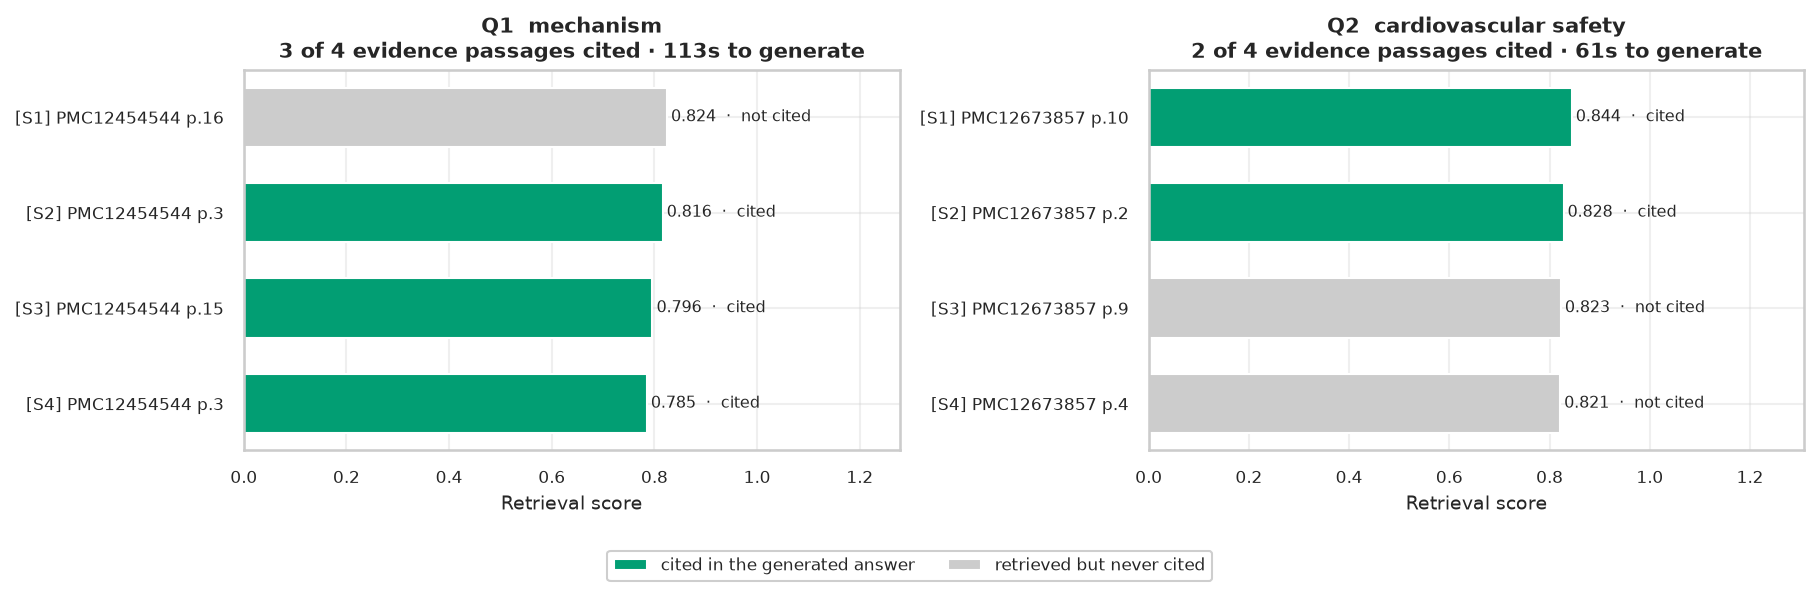

saved -> pde5_figures/fig07_answer_provenance.png  (300 DPI)
Q1  mechanism                인용 3/4  [S2], [S3], [S4]
                             → 원문 위치: PMC12454544 p.3, PMC12454544 p.15, PMC12454544 p.3
Q2  cardiovascular safety    인용 2/4  [S1], [S2]
                             → 원문 위치: PMC12673857 p.10, PMC12673857 p.2

인용되지 않은 근거는 프롬프트 토큰만 소모한 셈이다 — 재순위화(cross-encoder)로 줄일 수 있는 낭비다.
※ do_sample=False 라 같은 환경에서는 재현되지만, 모델·라이브러리 버전이 바뀌면 인용 패턴은 달라질 수 있다.


In [36]:
CITE_TAG = re.compile(r"\[S(\d+)\]")


def cited_ranks(answer_text: str, n_hits: int) -> set:
    """답변 본문의 [S1]·[S2] 태그 → 실제로 인용된 근거 번호 집합."""
    return {int(m) for m in CITE_TAG.findall(answer_text) if 1 <= int(m) <= n_hits}


panels = [("Q1  mechanism", answer_mechanism), ("Q2  cardiovascular safety", answer_safety)]
fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.6))

for ax, (title, ans) in zip(axes, panels):
    used   = cited_ranks(ans.answer, len(ans.hits))
    scores = [h.score for h in ans.hits]
    y      = np.arange(len(scores))
    ax.barh(y, scores, height=0.62, edgecolor="white",
            color=[CB[2] if (i + 1) in used else "0.80" for i in range(len(scores))])
    for i, hit in enumerate(ans.hits):
        mark = "cited" if (i + 1) in used else "not cited"
        ax.text(scores[i] + 0.008, i, f"{scores[i]:.3f}  ·  {mark}", va="center", fontsize=7.5)
    ax.set_yticks(y)
    ax.set_yticklabels([f"[S{i}] {h.passage.citation()}" for i, h in enumerate(ans.hits, 1)],
                       fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, max(scores) * 1.55)
    ax.set_xlabel("Retrieval score")
    ax.set_title(f"{title}\n{len(used)} of {len(ans.hits)} evidence passages cited "
                 f"· {ans.elapsed:.0f}s to generate", fontsize=10)

fig.tight_layout()
fig.legend(handles=[
    Patch(facecolor=CB[2], label="cited in the generated answer"),
    Patch(facecolor="0.80", label="retrieved but never cited"),
], loc="upper center", bbox_to_anchor=(0.5, -0.015), ncols=2, framealpha=0.95)
finish(fig, "fig07_answer_provenance")

for title, ans in panels:
    used = sorted(cited_ranks(ans.answer, len(ans.hits)))
    tags = ", ".join(f"[S{i}]" for i in used) or "(인용 태그 없음)"
    pages = ", ".join(ans.hits[i - 1].passage.citation() for i in used) or "-"
    print(f"{title:<28} 인용 {len(used)}/{len(ans.hits)}  {tags}")
    print(f"{'':<28} → 원문 위치: {pages}")
print("\n인용되지 않은 근거는 프롬프트 토큰만 소모한 셈이다 — 재순위화(cross-encoder)로 줄일 수 있는 낭비다.")
print("※ do_sample=False 라 같은 환경에서는 재현되지만, 모델·라이브러리 버전이 바뀌면 인용 패턴은 달라질 수 있다.")

### 8-4. 대조 실험 — 근거 없이 같은 질문을 던지면

RAG가 실제로 무엇을 바꾸는지 보려면 **같은 모델에게 근거 없이 물어봐야** 한다.
아래는 검색 단계를 건너뛰고 질문만 준 경우다.

In [37]:
def ask_without_evidence(question: str, max_new_tokens: int = 160) -> str:
    """대조 실험용: 검색 단계를 건너뛰고 같은 모델에게 질문만 던진다."""
    messages = [
        {"role": "system", "content": "You are a biomedical assistant. Be concise: at most six sentences."},
        {"role": "user", "content": question},
    ]
    return GENERATOR.reply(messages, max_new_tokens=max_new_tokens)


bare = ask_without_evidence(QUERY_SAFETY)
print("[근거 없음]")
print(bare)
print()
print("[근거 있음 — 위 RAG 답변 재출력]")
print(answer_safety.answer)

[근거 없음]
PDE5 inhibitors (like sildenafil, tadalafil, vardenafil) are generally safe for most people but may increase the risk of cardiovascular events, especially in patients with coronary artery disease or hypertension. They can also cause arrhythmias, particularly in those with preexisting heart conditions. Monitoring blood pressure and heart rate is recommended, and patients should consult their physician before use. Some studies suggest a potential risk of QT interval prolongation, which can lead to arrhythmias.

[근거 있음 — 위 RAG 답변 재출력]
The cardiovascular safety and arrhythmia risk of PDE5 inhibitors are discussed in the evidence. Studies show that PDE5 inhibitors may have negative effects in patients taking nitrates, those with life-threatening arrhythmias, unstable angina, or a history of myocardial infarction or heart failure [S2]. Additionally, PDE5 inhibitors may reduce cardiovascular risk in certain populations, such as high-risk patients with CVD, but they are not always bene

> **무엇을 비교해야 하나.** 두 답변의 *유창함*은 비슷할 것이다. 차이는 다른 데 있다.
>
> - **검증 가능성** — RAG 답변은 `[S1]` 을 따라가면 PDF 몇 쪽인지까지 확인된다.
>   근거 없는 답변은 맞는지 틀리는지 확인할 방법이 없다.
> - **최신성** — 코퍼스는 2026년 논문이다. 모델의 사전학습 지식은 그보다 오래됐다.
> - **범위 인식** — 근거에 없는 것을 물으면 RAG 쪽은 “자료에 없다”고 답할 수 있다.
>   이것이 환각 억제의 실질적 메커니즘이다.

In [38]:
# 코퍼스가 다루지 않는 질문 — 모델이 한계를 인정하는지 본다
OUT_OF_SCOPE = "What is the recommended tadalafil dose for pediatric pulmonary hypertension?"

probe_hits = RELOADED.query(OUT_OF_SCOPE, ENCODER, k=3)
print("검색 점수:", [round(h.score, 3) for h in probe_hits])
print("최고 점수가 0.55 아래면 근거가 사실상 없다는 신호다.\n")

out_of_scope = ASSISTANT.ask(OUT_OF_SCOPE, k=3)
out_of_scope.show()

검색 점수: [0.532, 0.501, 0.494]
최고 점수가 0.55 아래면 근거가 사실상 없다는 신호다.



Q. What is the recommended tadalafil dose for pediatric pulmonary hypertension?
The recommended tadalafil dose for pediatric pulmonary hypertension is not explicitly stated in the provided evidence. The evidence discusses the use of PDE-5 inhibitors in pediatric populations with congenital heart disease-induced pulmonary hypertension but does not specify a dosing guideline. Therefore, the answer cannot be determined from the given information. [S1]
근거 (3건, 생성 26.0초)
  [S1] PMC12673857 p.11       score=0.5321
  [S2] PMC12454544 p.18       score=0.5012
  [S3] PMC12673857 p.10       score=0.4936


## 9. 워크북 코드 ↔ 이 노트북 대응표

인쇄된 워크북 4절의 스니펫 `[4-1]~[4-4]` 는 개념을 최소한으로 보여주는 축약 코드다.
이 노트북은 같은 5단계를 **클래스 단위로 재설계**했기 때문에 이름이 다르다.
아래 표로 대응 관계를 확인하면 된다. **동작과 결과는 같다.**

| 워크북 | 이 노트북 | 비고 |
|--------|-----------|------|
| `[4-1]` `import fitz` | `import pymupdf` (실패 시 `fitz` 폴백) | `fitz` 는 구 이름, 현재 deprecated |
| `[4-1]` `nlp = English(); add_pipe('sentencizer')` | `SentenceSplitter` 클래스 내부 | 동일 API를 감싼 것 |
| `[4-1]` `num_sentence_chunk_size = 10` | `CFG.sentences_per_passage = 10` | 같은 값, 설정 dataclass로 이동 |
| — (워크북엔 없음) | `CFG.sentence_stride = 8` | **추가**: 창을 겹쳐 경계 손실 완화 |
| `[4-1]` 짧은 청크 제거 (≤30토큰) | `CFG.min_passage_tokens = 32` + `PassageBuilder` | 임계값만 32로 조정 |
| — (워크북엔 없음) | `looks_like_bibliography()`, `PdfTextLayer._strip_running_lines()` | **추가**: 참고문헌·머리말 제거 |
| `[4-2]` `SentenceTransformer("all-mpnet-base-v2")` | `ENCODER` (`CFG.embedder_id`) | 동일 모델, 768차원 |
| `[4-2]` `text_chunks_and_embeddings_df.csv` | `pde5_index/{vectors.npz, passages.jsonl, manifest.json}` | CSV 대신 벡터/메타 분리 저장 |
| `[4-2]` `pages_and_chunks_over_min_token_len` | `PASSAGES` (`list[Passage]`) | dict 리스트 → dataclass 리스트 |
| `[4-3]` `util.dot_score(a=q, b=embeddings)` | `PassageIndex.query()` 내부 | 동일 호출을 메서드로 감쌈 |
| `[4-3]` `torch.topk(dot_scores, k=5)` | `PassageIndex.query(..., k=CFG.top_k)` | 동일 |
| `[4-3]` `page_number` | `Passage.page_no` (1-base) | 오프셋 보정 없이 PDF 뷰어 쪽번호와 일치 |
| `[4-4]` `model_id = "google/gemma-2b-it"` | `CFG.generator_id = "Qwen/Qwen3-1.7B"` | gemma 는 gated → Qwen3 기본, 교체 가능 |
| `[4-4]` `dialogue_template` | `GroundedPrompt.compose()` | 근거 태그 `[S1]` 추가 |
| `[4-4]` `apply_chat_template(...)` | `LocalGenerator.render()` | `enable_thinking=False` 추가 |
| `[4-4]` `.to('cuda')` | `LocalGenerator._load_kwargs()` | CPU/GPU 자동 분기 |

## 10. 연습 문제

1. **stride 실험** — `CFG.sentence_stride` 를 10(겹침 없음)과 5(절반 겹침)로 바꿔
   패시지 수와 `QUERY_MECHANISM` 의 top-1 점수가 어떻게 변하는지 기록하라.
2. **필터 임계값** — `looks_like_bibliography()` 의 숫자 밀도 임계값 0.11 을 0.05 / 0.20 으로
   바꾸면 몇 개의 패시지가 더 걸러지는가? 본문이 잘못 걸러지는 경우는 없는가?
3. **재순위화 붙이기** — `sentence-transformers` 의 `CrossEncoder` 로 상위 20개를 다시 매겨
   상위 5개로 줄인 뒤, 답변 품질이 달라지는지 비교하라.
4. **코퍼스 확장** — `EPMC_SEARCH` 에 `query=PDE5 AND OPEN_ACCESS:Y` 를 주고
   논문 20편을 자동 수집하도록 `EuropePmcHarvester` 를 확장하라.
   (라이선스 표 출력은 반드시 유지할 것.)
5. **인용 검증기** — 답변의 `[S1]` 태그를 뽑아 실제 그 패시지에 근거가 있는지
   임베딩 유사도로 확인하는 함수를 작성하라.


## 11. 더 알아보기

- **RAG 원논문** — Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*, NeurIPS 2020. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401)
- **sentence-transformers 공식 문서** — <https://sbert.net/> (의미 검색, 재순위화, CrossEncoder)
- **PyMuPDF 텍스트 추출 가이드** — <https://pymupdf.readthedocs.io/en/latest/recipes-text.html>
- **spaCy sentencizer** — <https://spacy.io/api/sentencizer>
- **Qwen3 모델 카드** — <https://huggingface.co/Qwen/Qwen3-1.7B> (Apache-2.0)
- **Europe PMC REST API** — <https://europepmc.org/RestfulWebService> (서지·라이선스 조회, 오픈액세스 필터)
- **FAISS** — <https://faiss.ai/> (패시지가 수십만 개로 늘었을 때의 근사 최근접 탐색 — 위 “한계” 표 참고)
- **Creative Commons CC BY 4.0** — <https://creativecommons.org/licenses/by/4.0/> (이 노트북 코퍼스의 재사용 조건)


## 12. 한계와 주의

이 파이프라인은 **작동하는 최소 구성**이다. 실무에 올리려면 다음이 남는다.

| 한계 | 증상 | 개선 방향 |
|------|------|-----------|
| 내적 하나로만 검색 | 동의어·약어(PDE5i vs PDE-5 inhibitor)를 놓침 | BM25 키워드 검색과 **하이브리드**, RRF로 순위 병합 |
| 상위 k를 그대로 사용 | 4위·5위가 노이즈여도 프롬프트에 들어감 | **cross-encoder 재순위화** (`ms-marco-MiniLM`) |
| 전수 비교 (O(N)) | 패시지 수백 개라 괜찮지만 수십만이면 느림 | FAISS·HNSW 근사 최근접 탐색 |
| 표·그림을 못 읽음 | 수치가 표에만 있으면 검색 불가 | 표 전용 추출(`page.find_tables()`) 후 별도 색인 |
| 청크가 문서 구조를 모름 | Methods와 Discussion이 한 창에 섞임 | 섹션 헤딩 기반 분할 |
| 긴 패시지가 절단됨 | mpnet 입력 창은 384토큰 — 초과분은 인코딩에서 버려짐 | 창을 6문장으로 축소하거나 long-context 임베더 사용 |
| 페이지 경계에서 겹침 없음 | 청킹이 페이지 단위라 쪽이 바뀌면 stride가 끊김 | 문서 전체를 이어 붙인 뒤 청킹하고 쪽번호는 오프셋으로 추적 |
| 답변 검증 없음 | 모델이 `[S1]` 을 잘못 인용해도 통과 | 인용 태그 ↔ 근거 문장 일치 자동 검사 |
| 코퍼스 8편 | 질의 범위가 좁음 | Europe PMC 검색 API로 수십~수백 편 확장 |

**정직하게 남는 한계**

- **코퍼스가 8편뿐이다.** 인덱스에 없는 주제를 물으면 근거가 없으므로, 답변의 정확도는
  질문이 이 8편의 범위 안에 있는지에 전적으로 좌우된다. 범위 밖 질문은 8-4절에서 직접 확인한다.
- **`[S1]` 태그가 붙었다고 그 근거가 실제로 주장을 뒷받침한다는 뜻은 아니다.** 인용 태그와
  근거 문장의 일치는 자동 검증하지 않는다 — 사람이 원문을 열어 확인해야 한다.
- **생성 결과는 실행마다 조금씩 달라진다.** 검색 순위는 결정론적이지만 생성은 그렇지 않으므로,
  본문에 적힌 예시 답변과 여러분의 실행 결과가 글자 그대로 같지는 않다.
- **PDF 텍스트 레이어에 의존한다.** 스캔본(이미지 PDF)이나 표·그림 안의 수치는 애초에
  추출되지 않으므로 검색되지 않는다.
- **1.7B 로컬 모델이다.** 근거를 줘도 긴 추론이나 수치 비교에서는 틀릴 수 있다.
  이 노트북의 목적은 답변 품질의 최대치가 아니라 파이프라인의 동작 원리다.


## 13. 다음 실습

- 같은 6일차 [`nb1_scientific_agent.ipynb`](https://github.com/fourmodern/2026_aidrugdiscovery/blob/main/20260905/notebooks/nb1_scientific_agent.ipynb) —
  여기서 만든 것과 같은 “검색”을 **간이 TF-IDF로 축소**한 뒤, 구조화된 기억(LLM-wiki)과 맞세운다.
  이 노트북이 *검색을 잘 만드는 법*이라면, 그쪽은 *검색을 쓸지 기억을 쓸지 고르는 법*이다.
- `T004_nsclc_llm_coscientist.ipynb` — 검색·생성을 여러 에이전트로 나누는 구성.
